
<h2 style="color:Purple; font-family:; text-align:center;font-size:35px">
  ❁۪ ｡˚ Métricas de evaluación con RR Lyrae ❁۪ ｡˚
</h2>
<h1 style="color:Purple; font-size:13.5px;"> Student: </h1>Ornella Cañellas Arredondo 
<h1 style="color:Purple; font-size:13.5px;"> Rol:  </h1>202387002-1
<h1 style="color:Purple; font-size:13.5px;"> Professor and Assistant: </h1> Pía Amigo and Joseph Dabre


Basado en Machine learning for physics and Astronomy, Viviana Acquaviva (2023)

En esta actividad trabajaremos con un problema de clasificación binaria: distinguir estrellas **RR Lyrae** de otras estrellas a partir de sus colores fotométricos.

### Los objetivos son
- entrenar un clasificador simple
- evaluar su rendimiento con distintas métricas
- interpretar una matriz de confusión
- comparar accuracy con precision, recall y F1
- discutir qué métrica conviene según el objetivo científico

### Contexto
Las RR Lyrae son estrellas variables pulsantes muy importantes en astronomía. En un catálogo grande, un clasificador puede ayudarnos a encontrar candidatas RR Lyrae, pero no basta con mirar solo el accuracy.


### Descripción de los datos
El set de datos que usará para esta tarea es sobre estrellas. Las características son colores en distintos filtros del [sistema ugriz de SDSS](https://www.physics.unlv.edu/~jeffery/astro/photometry/photometry_sdss.html), que son un indicador si la estrella emite luz más azul, verde, amarilla o roja. Queremos predecir a partir de estas características si la estrella es un tipo especial de estrella llamada variable RR Lyrae.

- Las características son los colores u-g, g-r, r-i, i-z
- El target es 0 (no RRLyrae) y 1 (RRLyrae)

In [389]:
import pandas as pd
import numpy as np

import sklearn.tree
from sklearn.tree import DecisionTreeClassifier #modelo
from sklearn.tree import plot_tree #visualizacion arbol
from sklearn.model_selection import train_test_split
from sklearn import metrics #métricas
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate #validación cruzada
from sklearn.model_selection import KFold, StratifiedKFold #validación cruzada

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay #matriz de confusión

from scipy import stats

In [390]:
from io import StringIO
from IPython.display import Image
import pydotplus
from sklearn.tree import export_graphviz

In [391]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

font = {'size': 8}

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=8)
matplotlib.rc('ytick', labelsize=8)
matplotlib.rcParams['figure.dpi'] = 300

pd.set_option('display.max_columns', 100) #Para poder visualizar todas las columnas del dataframe
pd.set_option('display.max_colwidth', 100)

## Primer paso: exploración de los datos

Siempre es importante hacer una análisis exploratorio del conjunto de datos que trabajaremos. Leemos el archivo como un dataframe y extraemos información básica

In [392]:
#from google.colab import drive
#drive.mount('/content/drive')

In [393]:
#cargamos los datos como arreglos numpy
#features= np.loadtxt("/content/drive/MyDrive/Astronomia y Big data/notebooks_clases/RRLyrae_features_small.txt", delimiter=',')
#targets= np.loadtxt("/content/drive/MyDrive/Astronomia y Big data/notebooks_clases/RRLyrae_labels_small.txt", delimiter=',')
#features= np.loadtxt("/Users/klopito/Library/CloudStorage/Dropbox/cursos/clases_usm/2026_II/AST332/notebooks/RRLyrae_features_small.txt", delimiter=',')
#targets= np.loadtxt("/Users/klopito/Library/CloudStorage/Dropbox/cursos/clases_usm/2026_II/AST332/notebooks/RRLyrae_labels_small.txt", delimiter=',')
features= np.loadtxt("RRLyrae_features_small.txt", delimiter=',')
targets= np.loadtxt("RRLyrae_labels_small.txt", delimiter=',')

In [394]:
columnas = ["u-g", "g-r", "r-i", "i-z"]
df = pd.DataFrame(features, columns=columnas)
df["RR_Lyrae"] = targets.astype(int)
df.head()

,u-g,g-r,r-i,i-z,RR_Lyrae
0,0.311,0.714,0.093,0.204,0
1,0.332,0.965,0.122,0.032,0
2,0.394,1.019,0.147,0.096,0
3,0.285,0.865,0.120,0.039,0
4,0.386,0.977,0.181,0.080,0


### Preguntas
1. ¿Este es un problema de clasificación o regresión?
   Puede ser de clasificación, dado que basado en diversas características de las restas entre magnitudes y trazas de los mismos cuerpos se clasifica si son RR Lyrae o no.
3. ¿Es un problema binario o multiclase? Lo que se observa en el gráfico de abajo es un problema binario, dado que en el plot para colores u-g vs i-z, existen 2 clasificaciones tanto para las que son RR Lyrae como para las que no.
4. ¿Qué representa la variable objetivo?
   Es respecto a la característica que se quiere predecir o explicar a través de las gráficas, métrica, etc. En este caso del modelo, puede ser 0 para RR Lyrae y 1 para no RR_Lyrae, osea, se quiere explicar y predecir cuáles estrellas variables pulsantes son justamente RR Lyrae o no.
6. ¿Las clases están balanceadas o desbalanceadas?
   Yo diría que aún no se puede determinar con solo ver la gráfica de abajo, puesto que la cantidad de rojas se ve que es menor que las azules en su distribución, pero pueden estar sobrepuestas unas a las otras.
7. ¿Por qué esto podría ser importante al elegir una métrica de evaluación?
   Porque si es que se quiere el accuracy, pureza o completitud por ejemplo, se tiene que buscar la métrica de evaluación ideal de manera que represente el modelo. Es como que no hay una "respuesta universal", dado que en esta parte se tiene que profundizar para determinar los valores de las mismas métricas con la matriz de confusión, involucrando TP,TN,FP,FN. Por ejemplo el accuracy resulta simétrica en dos tipos de errores, tanto FN y FP, lo que significa que el modelo otorgará un mismo peso para ambas clases. Si se tiene un set de data desbalanceado, existe posibilidad de una mayor desclasificación (en fracción) para alguna clase, y que en verdad las clasificaciones correctas sean un poco porcentaje del data total y que las "misclassifications" sean mucho porcentaje para una clase en el data total. Por eso resulta importante ver si existe desbalanceamiento o no del data, para poder determinar si es que hay que maximizar la precisión para encontrar más pureza siendo que la precisión es sensible a los falso positivos, lo que se traduce en que se asegura una alta precisión para cada clasificación positiva conllevando alta confianza en la clasificación misma.

#### Haga una visualización de sólo dos columnas para revisar los colores de las RR Lyrae y las no RRLyrae

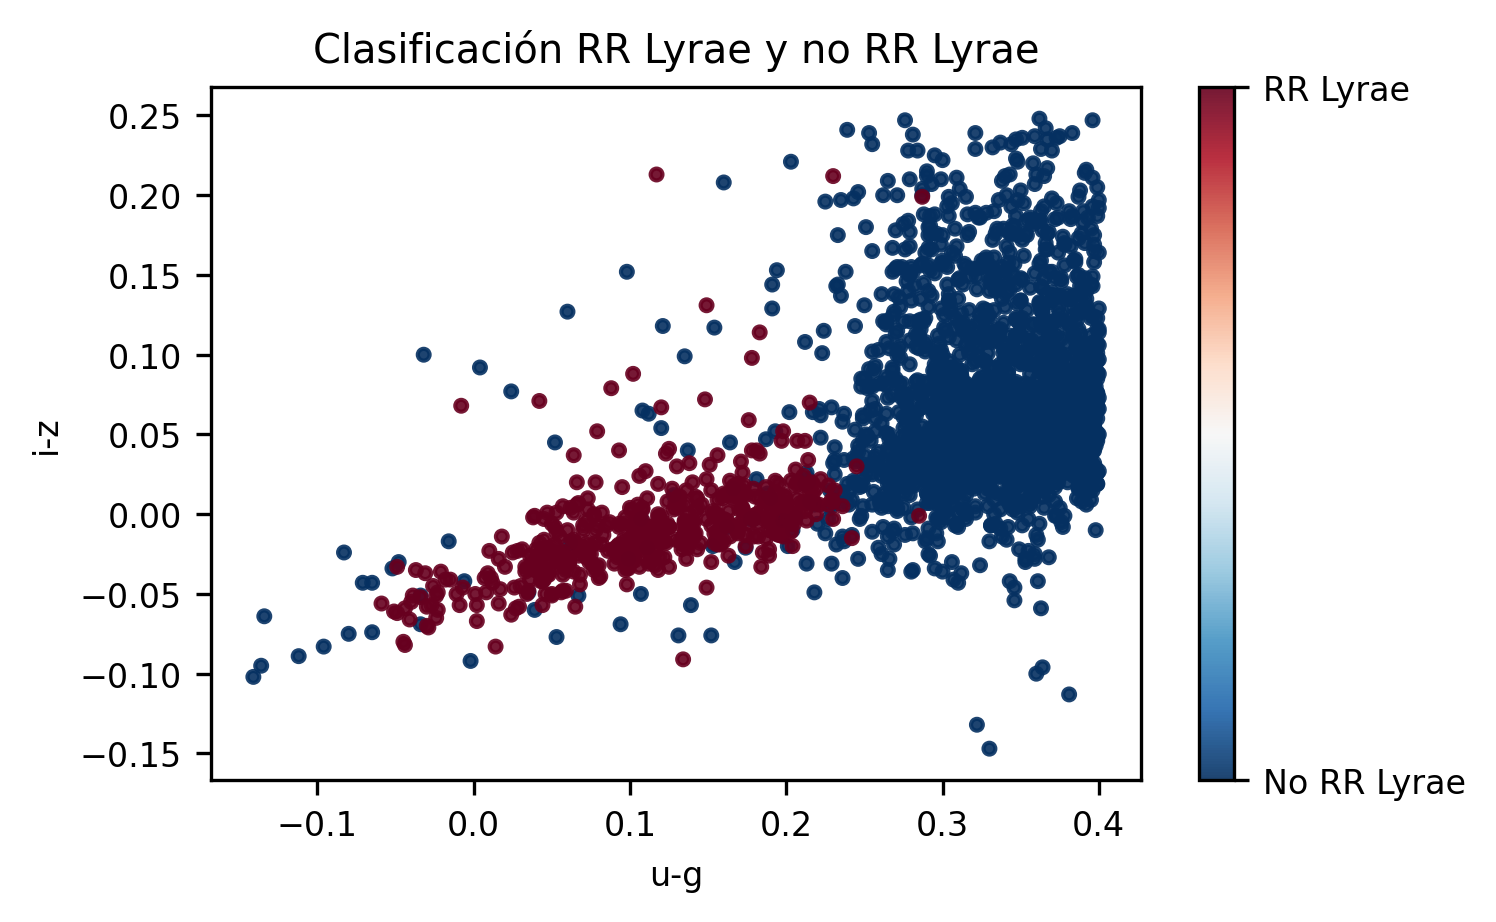

In [395]:
#Aquí las RR Lyrae son en colores muy burdeo y las no RR Lyrae en colores azules oscuros.
plt.figure(figsize=(5,3))
sc = plt.scatter(df['u-g'],df['i-z'],c=df['RR_Lyrae'],cmap='RdBu_r',vmin=0,vmax=1,s=8,alpha=0.9)
plt.xlabel("u-g")
plt.ylabel("i-z")
plt.title("Clasificación RR Lyrae y no RR Lyrae")
cbar = plt.colorbar(sc)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(["No RR Lyrae", "RR Lyrae"])
plt.show()

### Pregunta
1. ¿Se observan regiones donde las clases parecen separarse?
   Sí, se pueden ver zonas que tienden a separarse. Para los cuerpos azules en la diferencia u-g se extienden desde -0.15 a 0.4 (y un poquito más), mientras que en i-z desde -0.15 a 0.25, mientras que para los cuerpos rojos en u-g hay una extensión entre -0.05 a casi 0.3, y en el eje y i-z se extiende desde -0.10 a aproximadamente 0.20.
3. A simple vista, ¿esperarías que un árbol de decisión funcione razonablemente bien?
   Quizás no, debido a que hay muchos valores de rangos que pueden ser considerados y generar muchas divisiones.

#### Separe los datos en entrenamiento y prueba

In [396]:
X = df[["u-g", "g-r", "r-i", "i-z"]]
y = df["RR_Lyrae"]

In [397]:
#complete la celda
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=42)

In [398]:
X_train.shape

(1738, 4)

In [399]:
X_test.shape

(745, 4)

In [400]:
y_train.shape

(1738,)

In [401]:
y_test.shape

(745,)

### Antes de continuar

Las clases en este problema no están perfectamente balanceadas.

Piense en la forma en que podríamos separar los datos en entrenamiento y prueba, y responda:

1. ¿Qué problema podría ocurrir si hacemos la partición de manera completamente aleatoria, sin preocuparnos por la proporción de clases? Al realizar la partición aleatoriamente pueden clasificarse erróneamente las clases, por ejemplo podría occurrir que 10 estrellas variables pulsantes fueron clasificadas como no RR Lyrae, y eran por ejemplo solo 0.3% del total de su clase, y 10 otras fueron clasificadas erróneamente como RR Lyrae, que eran 20% de la clase total, entonces ahí hay que decidir bien cuál métrica podría representar mejor al modelo.
2. ¿Por qué eso podría afectar la evaluación del modelo? Porque podrían haber selecciones tanto en datos de training como test que afecten significativamente el rendimiento del resultado debido a variaciones en las propiedades estadísticas de las divisiones (splits). Aquello es relevante tanto para data set pequeños como grandes.
3. ¿Qué tipo de precaución cree que sería razonable tomar al construir los conjuntos de entrenamiento y prueba en este caso? Lo que se tiene que tener en cuenta cuando se escoge un set de entrenamiento/prueba se tiene que ver si se sub o sobreestima el rendimiento del algoritmo. El procedimiento conlleva el trato de una métrica de evaluación, para proveer un estimado de las incertezas que puedan existir provenientes de la variabilidad estadística del data. También se tiene que tener precaución que en las divisiones entre conjuntos de entrenamiento y prueba, donde puede perderse una cantidad significativa de datos de entrenamiento potenciales, puesto que los datos del conjunto de prueba no pueden formar parte del proceso de construcción del modelo, además puede ser costoso obtener datos. Eso puede resolverse con la validación cruzada, como validación cruzada k-fold, que consiste en dividir los datos del set de aprendizaje en k-folds de manera que cíclicamente se produzcan k iteraciones, se usa un fold como conjunto de prueba y los que quedan como k-1 folds del set de entrenamiento.

#### Ahora entrenaremos un árbol de decisión (modelo base)

In [402]:
model_tree = DecisionTreeClassifier(random_state=42)
model_tree.fit(X_train, y_train)
#entrene el modelo y genere las predicciones
y_pred=model_tree.predict(X_test)

In [403]:
df.RR_Lyrae.value_counts()
#Aquí cuerpos no RR Lyrae (0) son 2000 y los que sí son RR Lyrae (1) son 483

RR_Lyrae
0    2000
1     483
Name: count, dtype: int64

#### Visualicemos el árbol

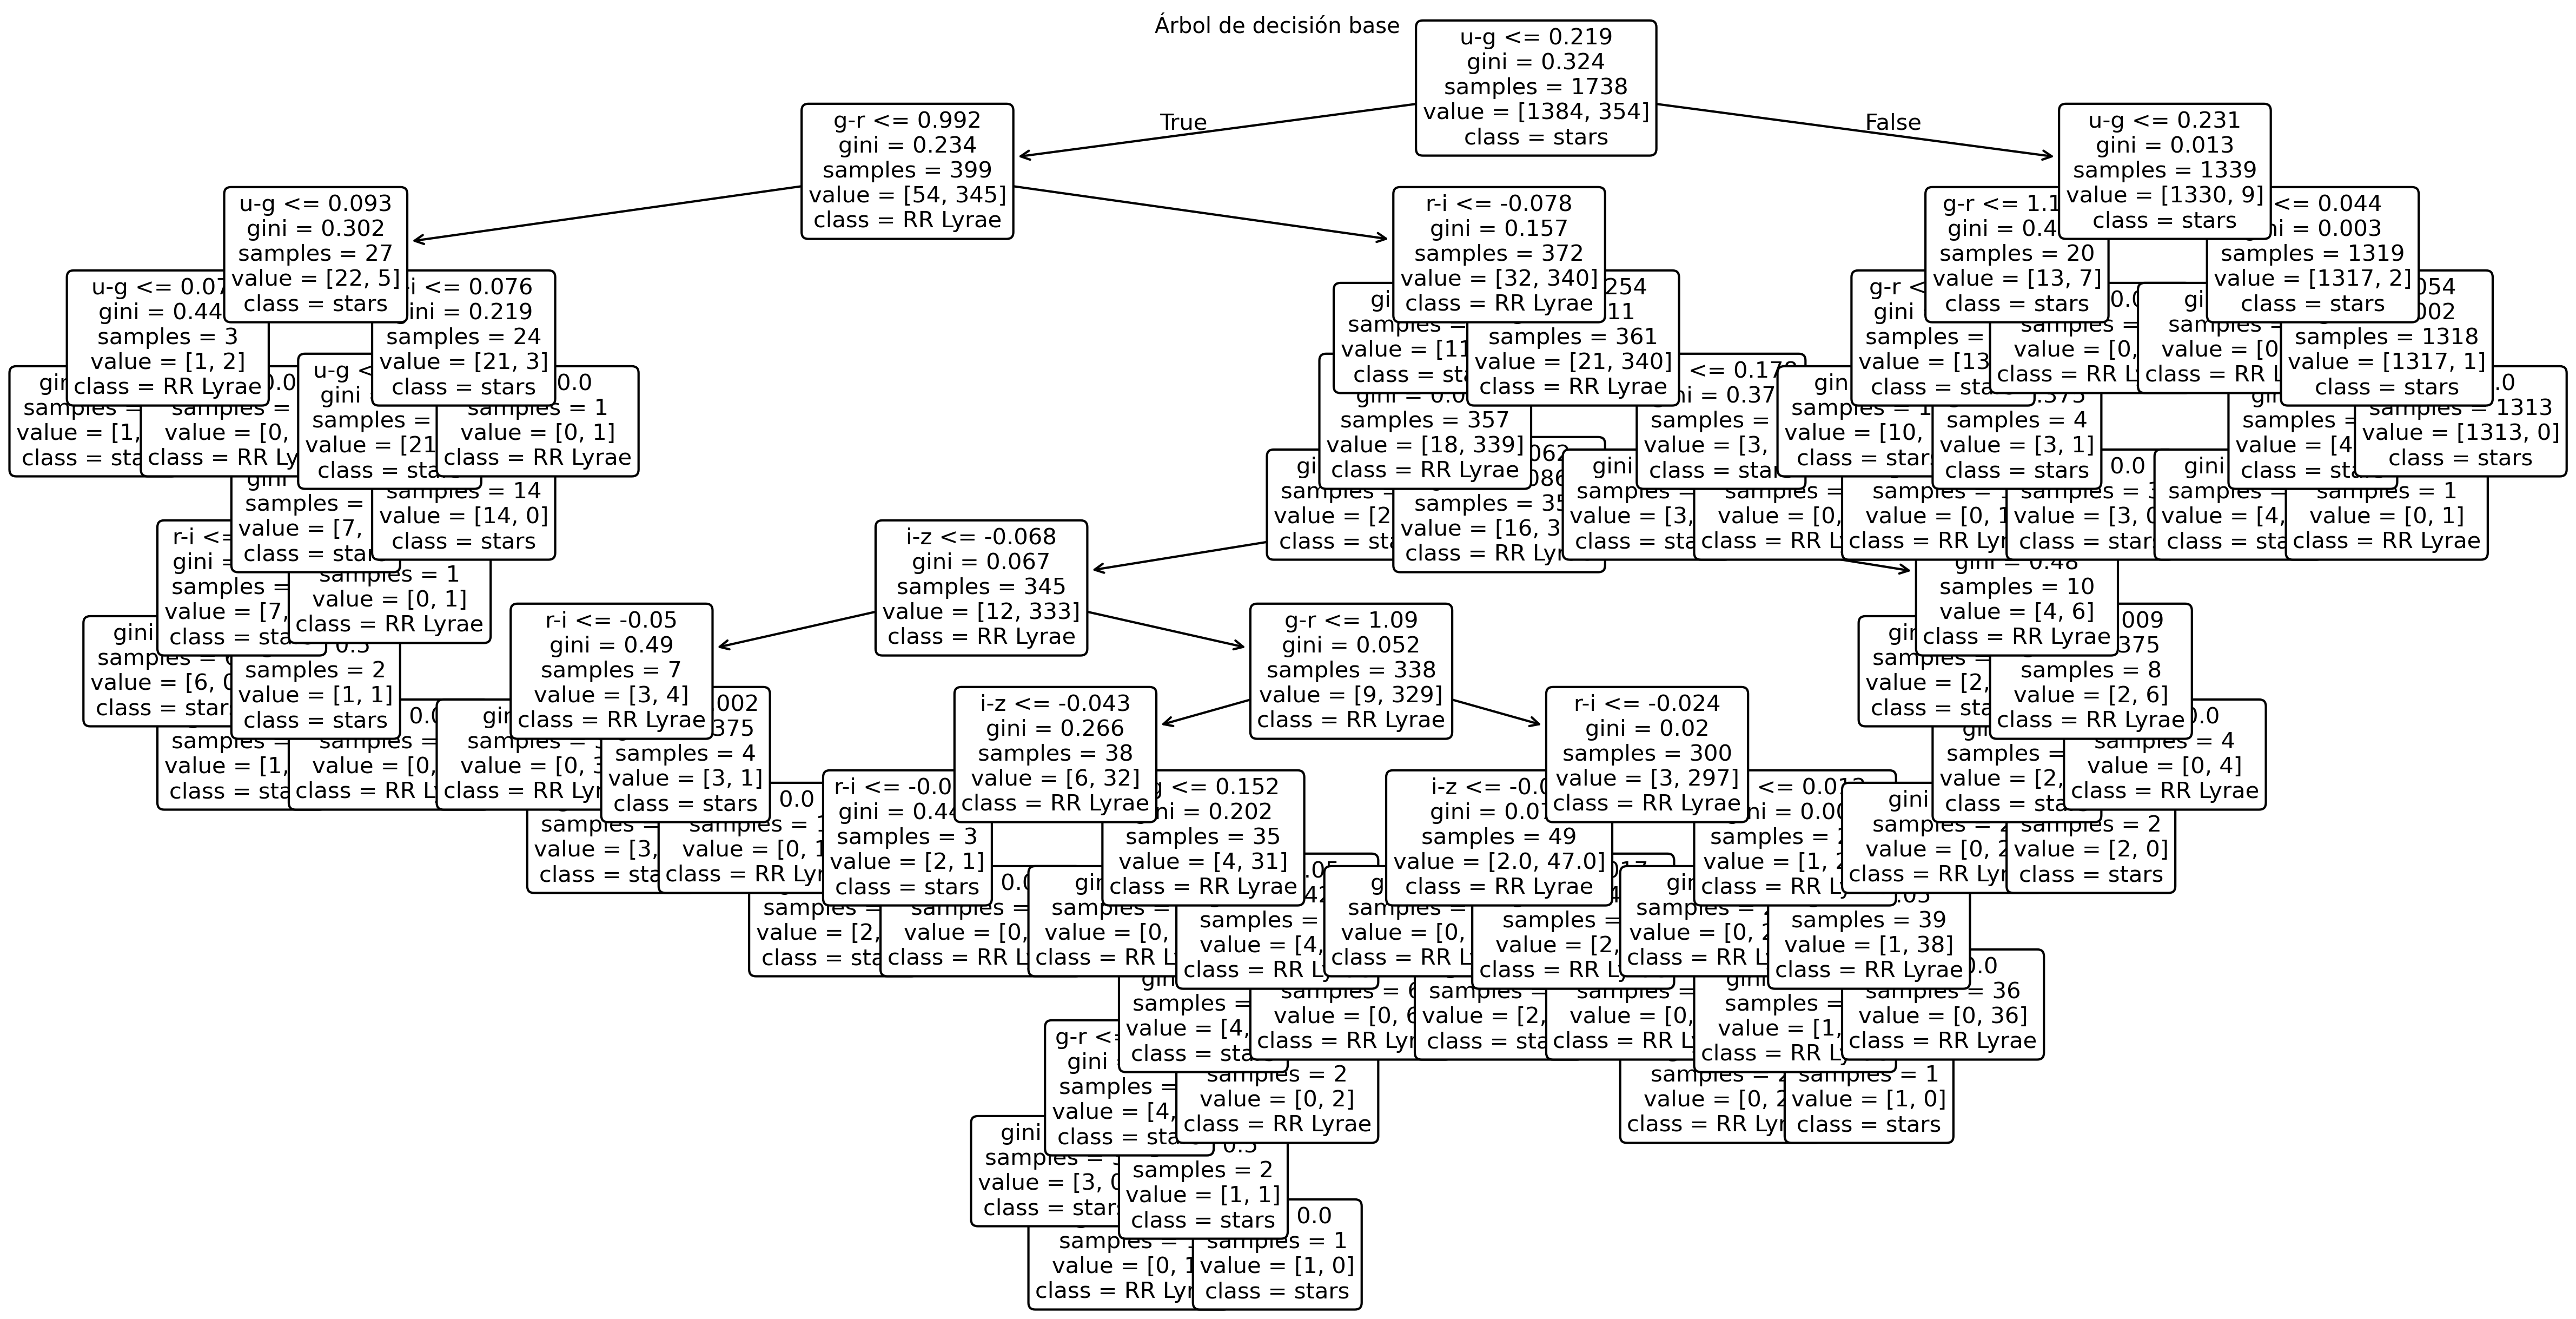

In [404]:
plt.figure(figsize=(20,10))

plot_tree(
    model_tree,
    feature_names=X.columns,
    class_names=["stars", "RR Lyrae"],
    filled=False,
    rounded=True,
    fontsize=10
)

plt.title("Árbol de decisión base")
plt.show()

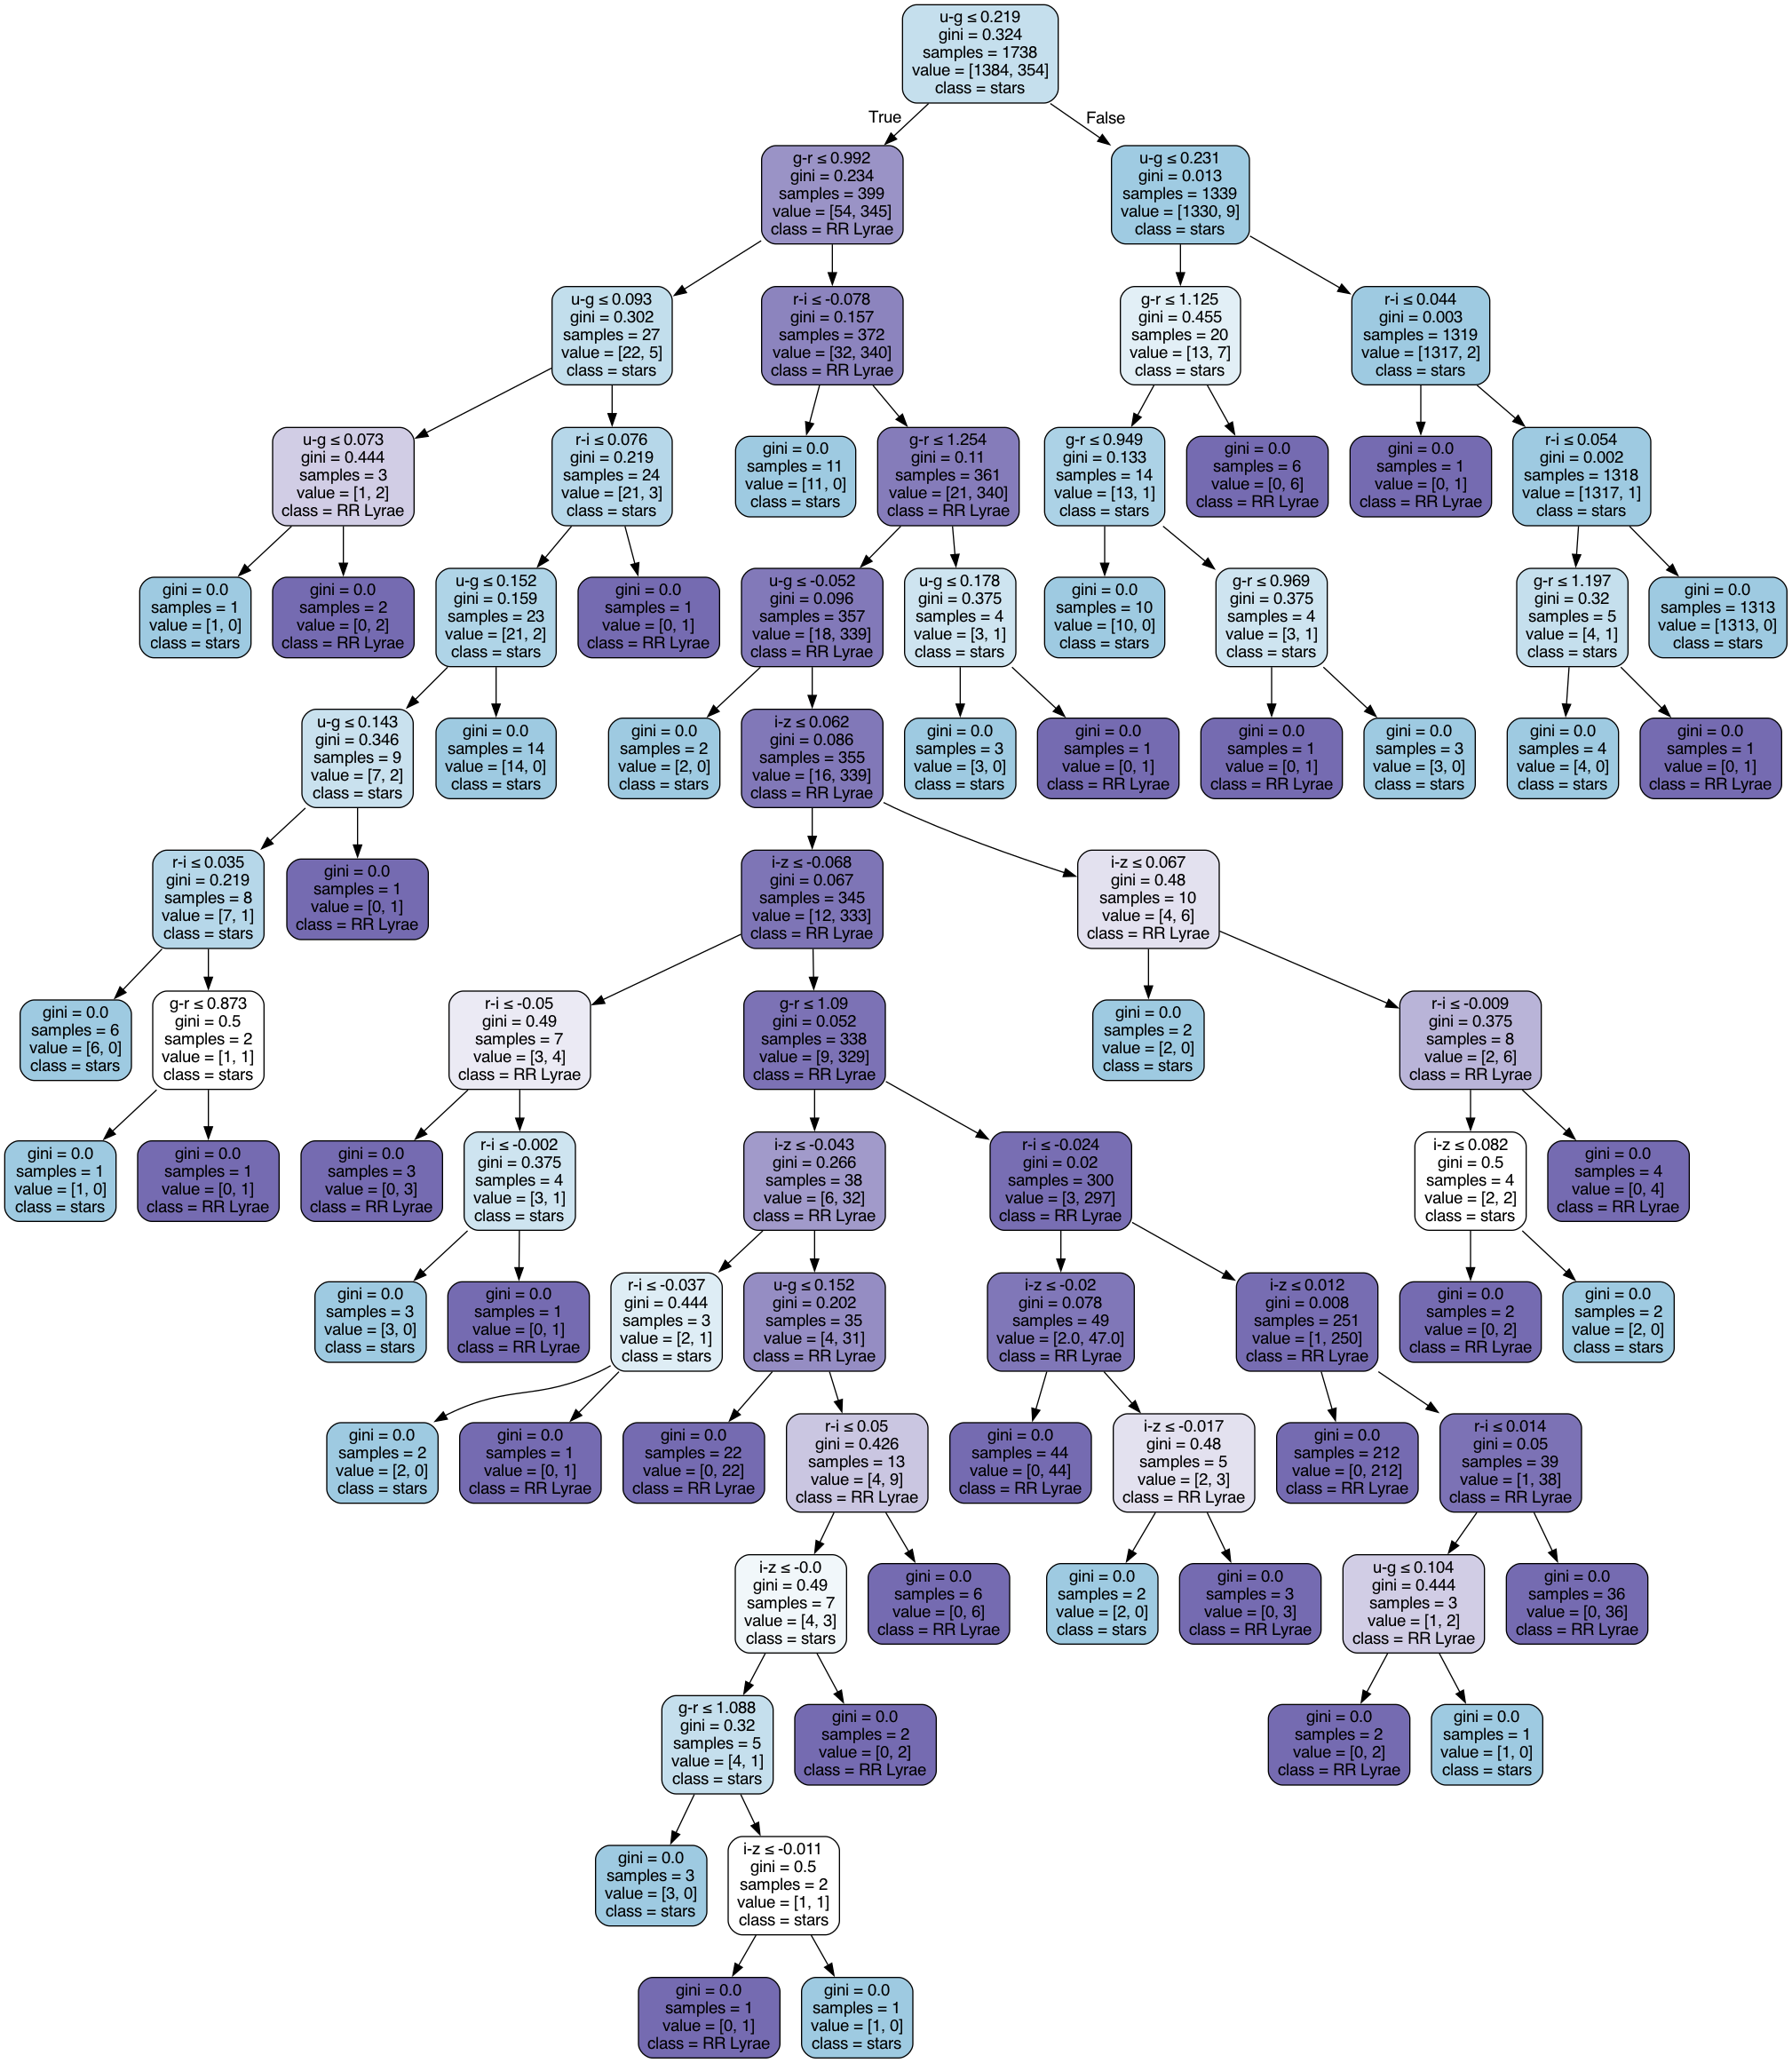

In [405]:
# Recordatorio: Las características siempre se permutan aleatoriamente en cada división.
# Por lo tanto, la mejor división encontrada puede variar, incluso con los mismos datos
# de entrenamiento y max_features=n_features, si la mejora del criterio es idéntica
# para varias divisiones enumeradas durante la búsqueda de la mejor división.
# Para obtener un comportamiento determinista durante el ajuste, random_state debe estar fijo.
#árbol está sobreajustando
dot_data = StringIO()
export_graphviz(
    model_tree,
    out_file=dot_data,
    feature_names=['u-g', 'g-r', 'r-i', 'i-z'],
    class_names=['stars', 'RR Lyrae'],
    filled=True,
    rounded=True,
    special_characters=True
)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue().replace("\n", ""))
nodes = graph.get_node_list()
for node in nodes:
    if node.get_label() and 'value = [' in node.get_label():

        values = [float(ii) for ii in node.get_label().split('value = [')[1].split(']')[0].split(',')]
        values = [int(255 * v / sum(values)) for v in values]

        if values[0] > values[1]:
            alpha = int(values[0] - values[1])
            alpha = '{:02x}'.format(alpha)
            color = '#9ecae1' + str(alpha)   # turquesa
        else:
            alpha = int(values[1] - values[0])
            alpha = '{:02x}'.format(alpha)
            color = '#756bb1' + str(alpha)   # magenta

        node.set_fillcolor(color)

Image(graph.create_png())

### Preguntas
Observe la estructura del árbol y responda brevemente:
1. ¿El árbol parece muy simple o bastante complejo? Justifique a partir del número de niveles o divisiones. El árbol se ve bastante complejo, hay demasiadas divisiones, pueden existir sobreajustes.
2. ¿Qué desventaja podría tener un árbol demasiado grande en un problema como este? Muchas divisiones en el árbol pueden provocar sobreajustes (mucho overfitting), se puede generalizar incorrectamente lo que realmente representa los datos del modelo además de sus clasificaciones, también puede volverse inestable y producir poca interpretabilidad. 

Aparte de la estructura del árbol, los modelos en si de Machine Learning (ML) sufren, como se había mencionado, de tanto o overfitting o underfitting, lo que se asocia con alto bias o alta varianza (eso se ve más adelante en conjunto a su optimización para el modelo). Si un modelo tiene un alto bias el modelo es propenso a "subfittear" (underfitting), lo que provoca que claramente se pierda información importante, no captura la complejidad de la relación existente entre datos input y output. Mientras que modelos con alta varianza son propensos a "sobrefittear" (overfitting) y generalizan mal, pues junto al training set a sobreajustado. Eso ocurre cuando el modelo es muy complejo y en el proceso se incluyen fluctuaciones y outliers si se le incluyen características que no ayudan a concluir y resultan como ruido, provocando por ejemplo que los test scores sean bajos.

#### Miremos las métricas accuracy para set de entrenamiento y prueba

In [406]:
print(metrics.accuracy_score(y_train, model_tree.predict(X_train))) #train score

print(metrics.accuracy_score(y_test, model_tree.predict(X_test))) #test score

1.0
0.9651006711409396


Como se puede observar para las métricas accuracy (fracción de clasificaciones correctas) para el set de entrenamiento y prueba, estas son 1.0 (aludiendo al 100%) y 0.9651 (aludiendo al 96.51%). Luego el accuracy para el set de entrenamiento es muy bueno pues le acierta un 100% correctamente a las clasificaciones.

#### Otras métricas

In [407]:
print("Precision:", metrics.precision_score(y_test, y_pred))
print("Recall   :", metrics.recall_score(y_test, y_pred))
print("F1-score :", metrics.f1_score(y_test, y_pred))

Precision: 0.8759124087591241
Recall   : 0.9302325581395349
F1-score : 0.9022556390977443


Para otras métricas, como la precisión (pureza), el recall (completitud) y F1-score, se tienen valores de alrededor 87%, 93% y 90%, respectivamente.

In [408]:
#Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
cm

array([[599,  17],
       [  9, 120]])

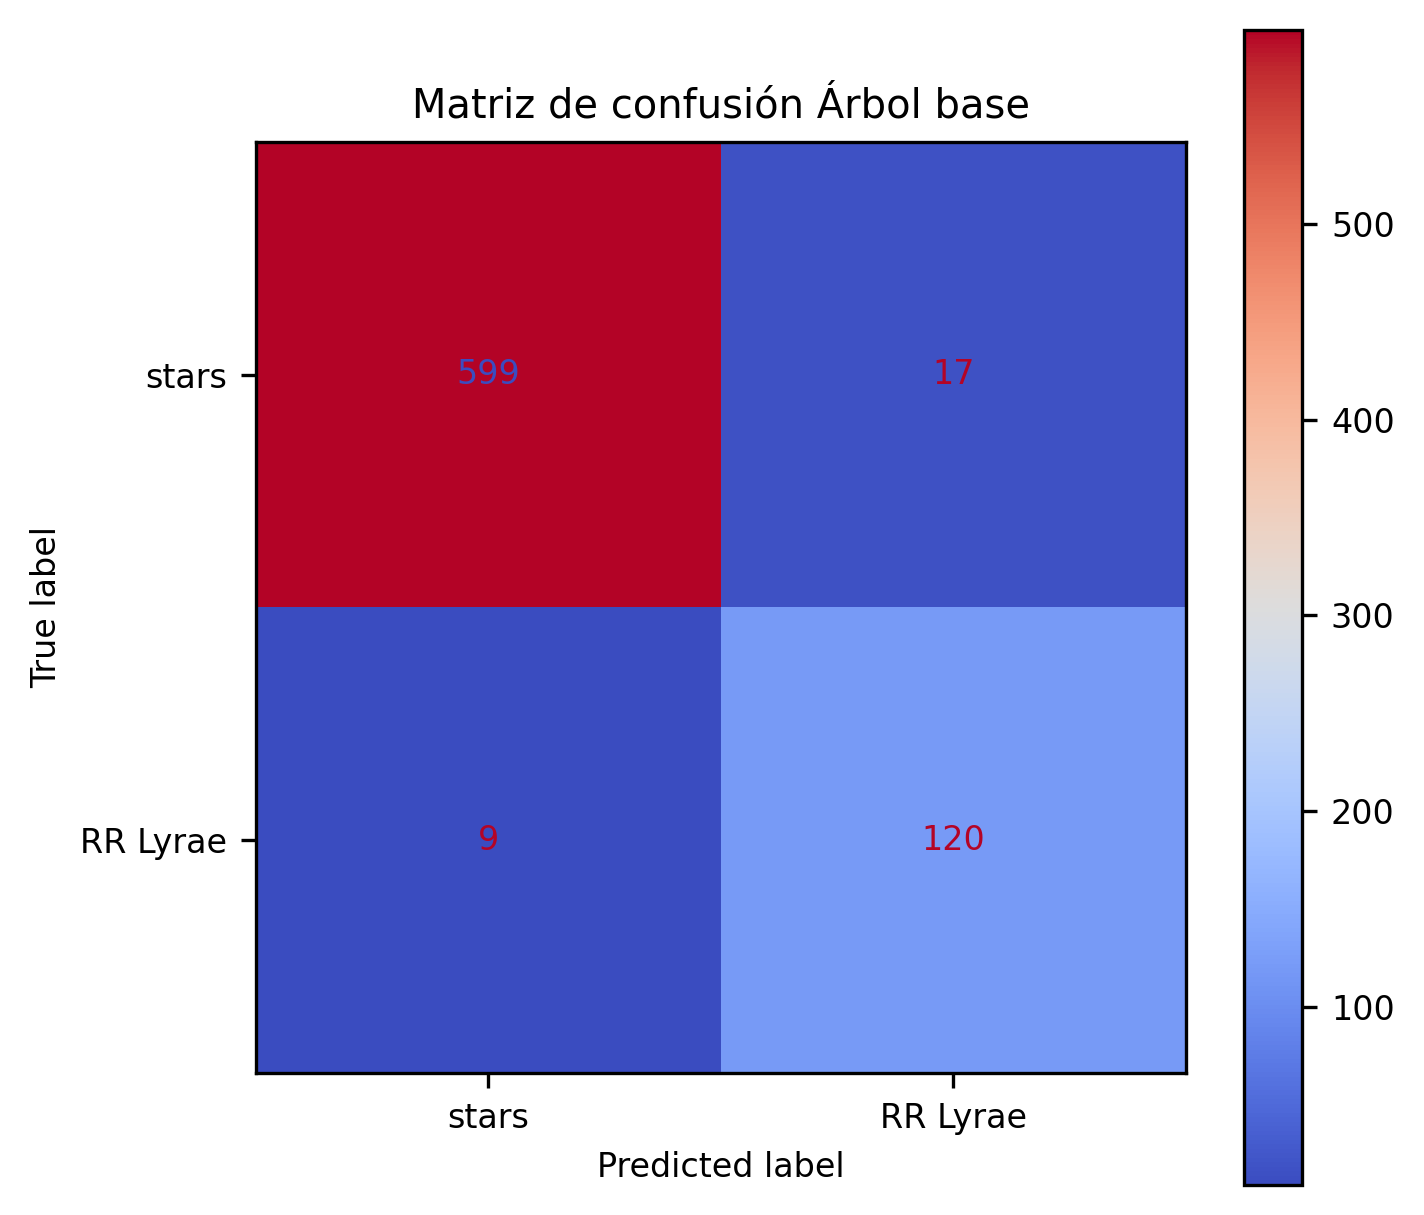

In [409]:
fig, ax = plt.subplots(figsize=(5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["stars", "RR Lyrae"])
disp.plot(cmap="coolwarm", ax=ax, colorbar=True)
plt.title("Matriz de confusión Árbol base")
plt.show()

#### A partir de la matriz de confusión obtenida:
1.  Identifique los valores de:
   - verdaderos positivos (TP), estos son 599 (stars-stars)
   - verdaderos negativos (TN), estos son 120 (RR Lyrae-RR Lyrae)
   - falsos positivos (FP), estos son 9 (RR Lyrae-stars)
   - falsos negativos (FN), estos son 17 
2. Calcule las métricas "a mano"
Para las métricas:
- Precisión (Pureza) = TP/TP+FP = 599/599+9 = 0.9884
- Recall (Completitud) = TP/TP+FN = 599/599+17 = 0.9724
- F1 Score = (2*0.9884*0.9724)/(0.9884+0.9724) = 0.9803
- Curva ROC y AUC:
  - para la tasa de verdaderos positivos TPR = recall = TP/TP+FN = 0.9724
  - para FPR = FP/TP+TN = 9/599+120 = 0.0125
  - Para este caso se puede decir que la métrica se acerca a un clasificador casi perfecto, puesto que teniendo en cuenta la gráfica TPR (eje y) y FPR (eje x) mientras TPR más se acerque a 1 mejor es y para FPR mientras más se acerque a 0, resulta ser mejor.

### Preguntas
1. Explique con sus palabras qué significa, en este problema:
   - un falso positivo, sería un elemento que fue identificado como positivo RR Lyrae pero que no lo es.
   - un falso negativo, sería un elemento que no fue identificado como RR Lyrae y en realidad sí lo es.

2. Si el objetivo científico fuera encontrar la mayor cantidad posible de RR Lyrae, ¿qué tipo de error preocuparía más? El tipo de error que preocuparía más sería el falso negativo (FN), porque si se quiere encontrar los que sí sean RR Lyrae, podría suceder que no sea clasificado y que pase por alto, cuando en verdad el elemento si es RR Lyrae.

3. Si el objetivo fuera construir una muestra final más limpia, ¿qué tipo de error preocuparía más? Para una muestra final más limpia, se requeriría de precisión para la pureza, luego el tipos de error falso positivos (FP), dado que se estarían clasificando RR Lyrae cuando en realidad no es RR Lyrae. Para ello se busca maximizar la precisión, debido a que para la muestra más limpia una alta pureza es conveniente. Además, como la precisión es sensible sólo a los falso positivos, una alta precisión respalda que cada clasificación positiva tenga un alto nivel de confianza.

#### Todo parece funcionar bien, pero sólo hicimos un split. Necesitamos que el resultados sea robusto. Para esto, implementaremos Cross-validation usando [k-fold](https://scikit--learn-org.translate.goog/stable/modules/generated/sklearn.model_selection.KFold.html?_x_tr_sl=en&_x_tr_tl=es&_x_tr_hl=es&_x_tr_pto=tc)

In [410]:
# Esta es la versión estándar. Importante: no baraja los datos, por lo que si tus
# ejemplos positivos están todos al principio o al final, podría llevar a resultados
# desastrosos.
cv1 = KFold(n_splits = 5)
#Esta es la versión 2: se ha añadido el barajado (¡recomendado!)
#Tener el set barajado o "revuelto" es importante porque podría existir orden en los datos
cv2 = KFold(shuffle = True, n_splits = 5, random_state=5)  
# LA ESTRATIFICACIÓN asegura que las distribuciones de clases en cada división se
# asemejen a las del conjunto de datos completo.
cv3 = StratifiedKFold(shuffle = True, n_splits = 5, random_state=5)


### Efecto de la estratificación: veamos el conteo de clases en cada conjunto de divisiones.

In [411]:
cv1.split(X, y)

<generator object _BaseKFold.split at 0x16bdca130>

In [412]:
for train, test in cv1.split(X, y):
    print('train -  {}   |   test -  {}'.format(
    np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1503  483]   |   test -  [497]
train -  [1503  483]   |   test -  [497]
train -  [1503  483]   |   test -  [497]
train -  [1504  483]   |   test -  [496]
train -  [1987]   |   test -  [ 13 483]


In [413]:
for train, test in cv2.split(X, y):
    print('train -  {}   |   test -  {}'.format(
    np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1600  386]   |   test -  [400  97]
train -  [1610  376]   |   test -  [390 107]
train -  [1587  399]   |   test -  [413  84]
train -  [1599  388]   |   test -  [401  95]
train -  [1604  383]   |   test -  [396 100]


In [414]:
for train, test in cv3.split(X, y):
    print('train -  {}   |   test -  {}'.format(
    np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1600  386]   |   test -  [400  97]
train -  [1600  386]   |   test -  [400  97]
train -  [1600  386]   |   test -  [400  97]
train -  [1600  387]   |   test -  [400  96]
train -  [1600  387]   |   test -  [400  96]


### La función [`cross_validate`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html#sklearn.model_selection.cross_validate) proporciona los puntajes (especificados por el parámetro de evaluación elegido), en forma de diccionario (en forma concepto y sus datos agrupados como array para este caso).

In [415]:
scores1 = cross_validate(DecisionTreeClassifier(), X, y, cv = cv1, scoring = 'accuracy')

scores2 = cross_validate(DecisionTreeClassifier(), X, y, cv = cv2, scoring = 'accuracy')

scores3 = cross_validate(DecisionTreeClassifier(), X, y, cv = cv3, scoring = 'accuracy')

In [416]:
scores1

{'fit_time': array([0.00906706, 0.00555396, 0.00417376, 0.00363493, 0.00092173]),
 'score_time': array([0.00278282, 0.00201607, 0.00113726, 0.00105286, 0.00091124]),
 'test_score': array([0.97987928, 0.98390342, 0.96981891, 0.96572581, 0.02620968])}

In [417]:
scores2

{'fit_time': array([0.00293112, 0.00298405, 0.00299501, 0.00258803, 0.00222707]),
 'score_time': array([0.00092292, 0.00089192, 0.00084305, 0.00082707, 0.00091195]),
 'test_score': array([0.96579477, 0.96177062, 0.98792757, 0.96572581, 0.94556452])}

In [418]:
scores3

{'fit_time': array([0.00263309, 0.00213599, 0.00251913, 0.00252485, 0.00255704]),
 'score_time': array([0.00075698, 0.00073814, 0.00070977, 0.00075316, 0.00081086]),
 'test_score': array([0.97987928, 0.96780684, 0.96780684, 0.97379032, 0.95967742])}

De estos conceptos solo nos interesa el 'test_score'. Además, si se ven algunas diferencias (o algo está raro), ahi que revisar. Junto a ello se intenta de que la desviación estándar no sea alta.

#### Calculamos el promedio y $\sigma$ para el concepto que interesa que es el "test_score"

In [419]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['test_score'].std()))

0.785 0.380


In [420]:
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['test_score'].std()))

0.965 0.014


In [421]:
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['test_score'].std()))

0.970 0.007


La validación cruzada sin barajar (`cv1`) produce un resultado muy inestable, con una desviación estándar extremadamente alta. Esto ocurre porque los datos están ordenados por clase, de modo que algunos folds no representan bien el problema completo.

Al activar el barajado (`cv2`), el rendimiento mejora drásticamente y la dispersión disminuye (que es lo deseado). Sin embargo, el método que resulta más apropiado para este problema es `StratifiedKFold` (`cv3`), ya que además de mezclar los datos, conserva aproximadamente la proporción de clases en cada fold.

En problemas de clasificación desbalanceada, esta última estrategia suele ser la más recomendable.

In [422]:
scores1 = cross_validate(DecisionTreeClassifier(random_state=1), X,y, cv = cv1, scoring = 'recall')

scores2 = cross_validate(DecisionTreeClassifier(random_state=1), X,y, cv = cv2, scoring = 'recall')

scores3 = cross_validate(DecisionTreeClassifier(random_state=1), X,y, cv = cv3, scoring = 'recall')

/opt/homebrew/Caskroom/miniforge/base/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Caskroom/miniforge/base/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Caskroom/miniforge/base/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt

In [423]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['test_score'].std()))
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['test_score'].std()))
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['test_score'].std()))

nan nan
0.903 0.016
0.925 0.019


### ¿Por qué aparece este warning?

En algunos folds generados por `KFold` sin barajado, el conjunto de prueba contiene solo ejemplos de una clase. En ese caso, el recall de la clase positiva (RR Lyrae) no puede calcularse, porque no hay positivos reales en ese fold.

Esto muestra que una estrategia de partición inadecuada puede hacer que la evaluación sea inestable, engañosa o incluso inválida.

#### También extraeremos los train scores, que nos servirán cuando estemos diagnosticando el modelo a través de bias vs variance.¶

In [424]:
scores1 = cross_validate(DecisionTreeClassifier(), X,y, cv = cv1, scoring = 'recall', \
                         return_train_score = True)

scores2 = cross_validate(DecisionTreeClassifier(), X,y, cv = cv2, scoring = 'recall', \
                         return_train_score = True)

scores3 = cross_validate(DecisionTreeClassifier(), X,y, cv = cv3, scoring = 'recall',
                         return_train_score = True)

/opt/homebrew/Caskroom/miniforge/base/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Caskroom/miniforge/base/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Caskroom/miniforge/base/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt

In [425]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['train_score'].mean()))
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['train_score'].mean()))
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['train_score'].mean()))

nan nan
0.912 1.000
0.925 1.000


Como se puede ver, la fracción de los promedios para los test score son nan, 0.912 y 0.925, mientras que para los train score son nan,1.0 y 1.0.

### La función  `cross_validate` es útil para calcular el puntaje, pero no produce etiquetas predichas.

#### Estas pueden obtenerse utilizando la función [`cross_val_predict`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_predict.html), que guarda las predicciones para cada uno de los k-folds de prueba y las compila juntas.


In [426]:
model1 = DecisionTreeClassifier(random_state = 3)
y_cv3 = cross_val_predict(model1, X,y, cv = cv3)
# Estas son las predicciones,
# y son independientes del parámetro de evaluación

In [427]:
metrics.confusion_matrix(targets,y_cv3)

array([[1955,   45],
       [  33,  450]])

### Sin embargo, las cosas pueden cambiar si uso un esquema de validación cruzada diferente:

In [428]:
model2 = DecisionTreeClassifier(random_state = 3)
y_cv2 = cross_val_predict(model2, X,y, cv = cv2)

In [429]:
np.sum(y_cv3-y_cv2)

np.int64(10)

In [430]:
np.sum(y_cv2)

np.int64(485)

In [431]:
np.sum(y_cv3 != y_cv2) #comparando las predicciones

np.int64(52)

In [432]:
metrics.confusion_matrix(targets,y_cv2)

array([[1955,   45],
       [  43,  440]])

In [433]:
metrics.confusion_matrix(targets,y_cv3)

array([[1955,   45],
       [  33,  450]])

In [434]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=5,
                        n_jobs=-1, train_sizes=np.linspace(0.2, 1.0, 5), scoring = 'accuracy'):
    """
    Generate a simple plot of the test and training learning curve.

    Parameters
    ----------
    estimator : object type that implements the "fit" and "predict" methods
        An object of that type which is cloned for each validation.

    title : string
        Title for the chart.

    X : array-like, shape (n_samples, n_features)
        Training vector, where n_samples is the number of samples and
        n_features is the number of features.

    y : array-like, shape (n_samples) or (n_samples, n_features), optional
        Target relative to X for classification or regression;
        None for unsupervised learning.

    ylim : tuple, shape (ymin, ymax), optional
        Defines minimum and maximum yvalues plotted.

    cv : int, cross-validation generator or an iterable, optional
        Determines the cross-validation splitting strategy.
        Possible inputs for cv are:
          - None, to use the default 3-fold cross-validation,
          - integer, to specify the number of folds.
          - :term:`CV splitter`,
          - An iterable yielding (train, test) splits as arrays of indices.

        For integer/None inputs, if ``y`` is binary or multiclass,
        :class:`StratifiedKFold` used. If the estimator is not a classifier
        or if ``y`` is neither binary nor multiclass, :class:`KFold` is used.

        Refer :ref:`User Guide <cross_validation>` for the various
        cross-validators that can be used here.

    n_jobs : int or None, optional (default=None)
        Number of jobs to run in parallel.
        ``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.
        ``-1`` means using all processors. See :term:`Glossary <n_jobs>`
        for more details.

    train_sizes : array-like, shape (n_ticks,), dtype float or int
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve. If the dtype is float, it is regarded as a
        fraction of the maximum size of the training set (that is determined
        by the selected validation method), i.e. it has to be within (0, 1].
        Otherwise it is interpreted as absolute sizes of the training sets.
        Note that for classification the number of samples usually have to
        be big enough to contain at least one sample from each class.
        (default: np.linspace(0.1, 1.0, 5))
    """
    plt.figure(figsize=(10,6))
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel(str(scoring))

    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring = scoring, shuffle=True, random_state=42)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Test score from cross-validation")

    plt.legend(loc="best")
    return plt

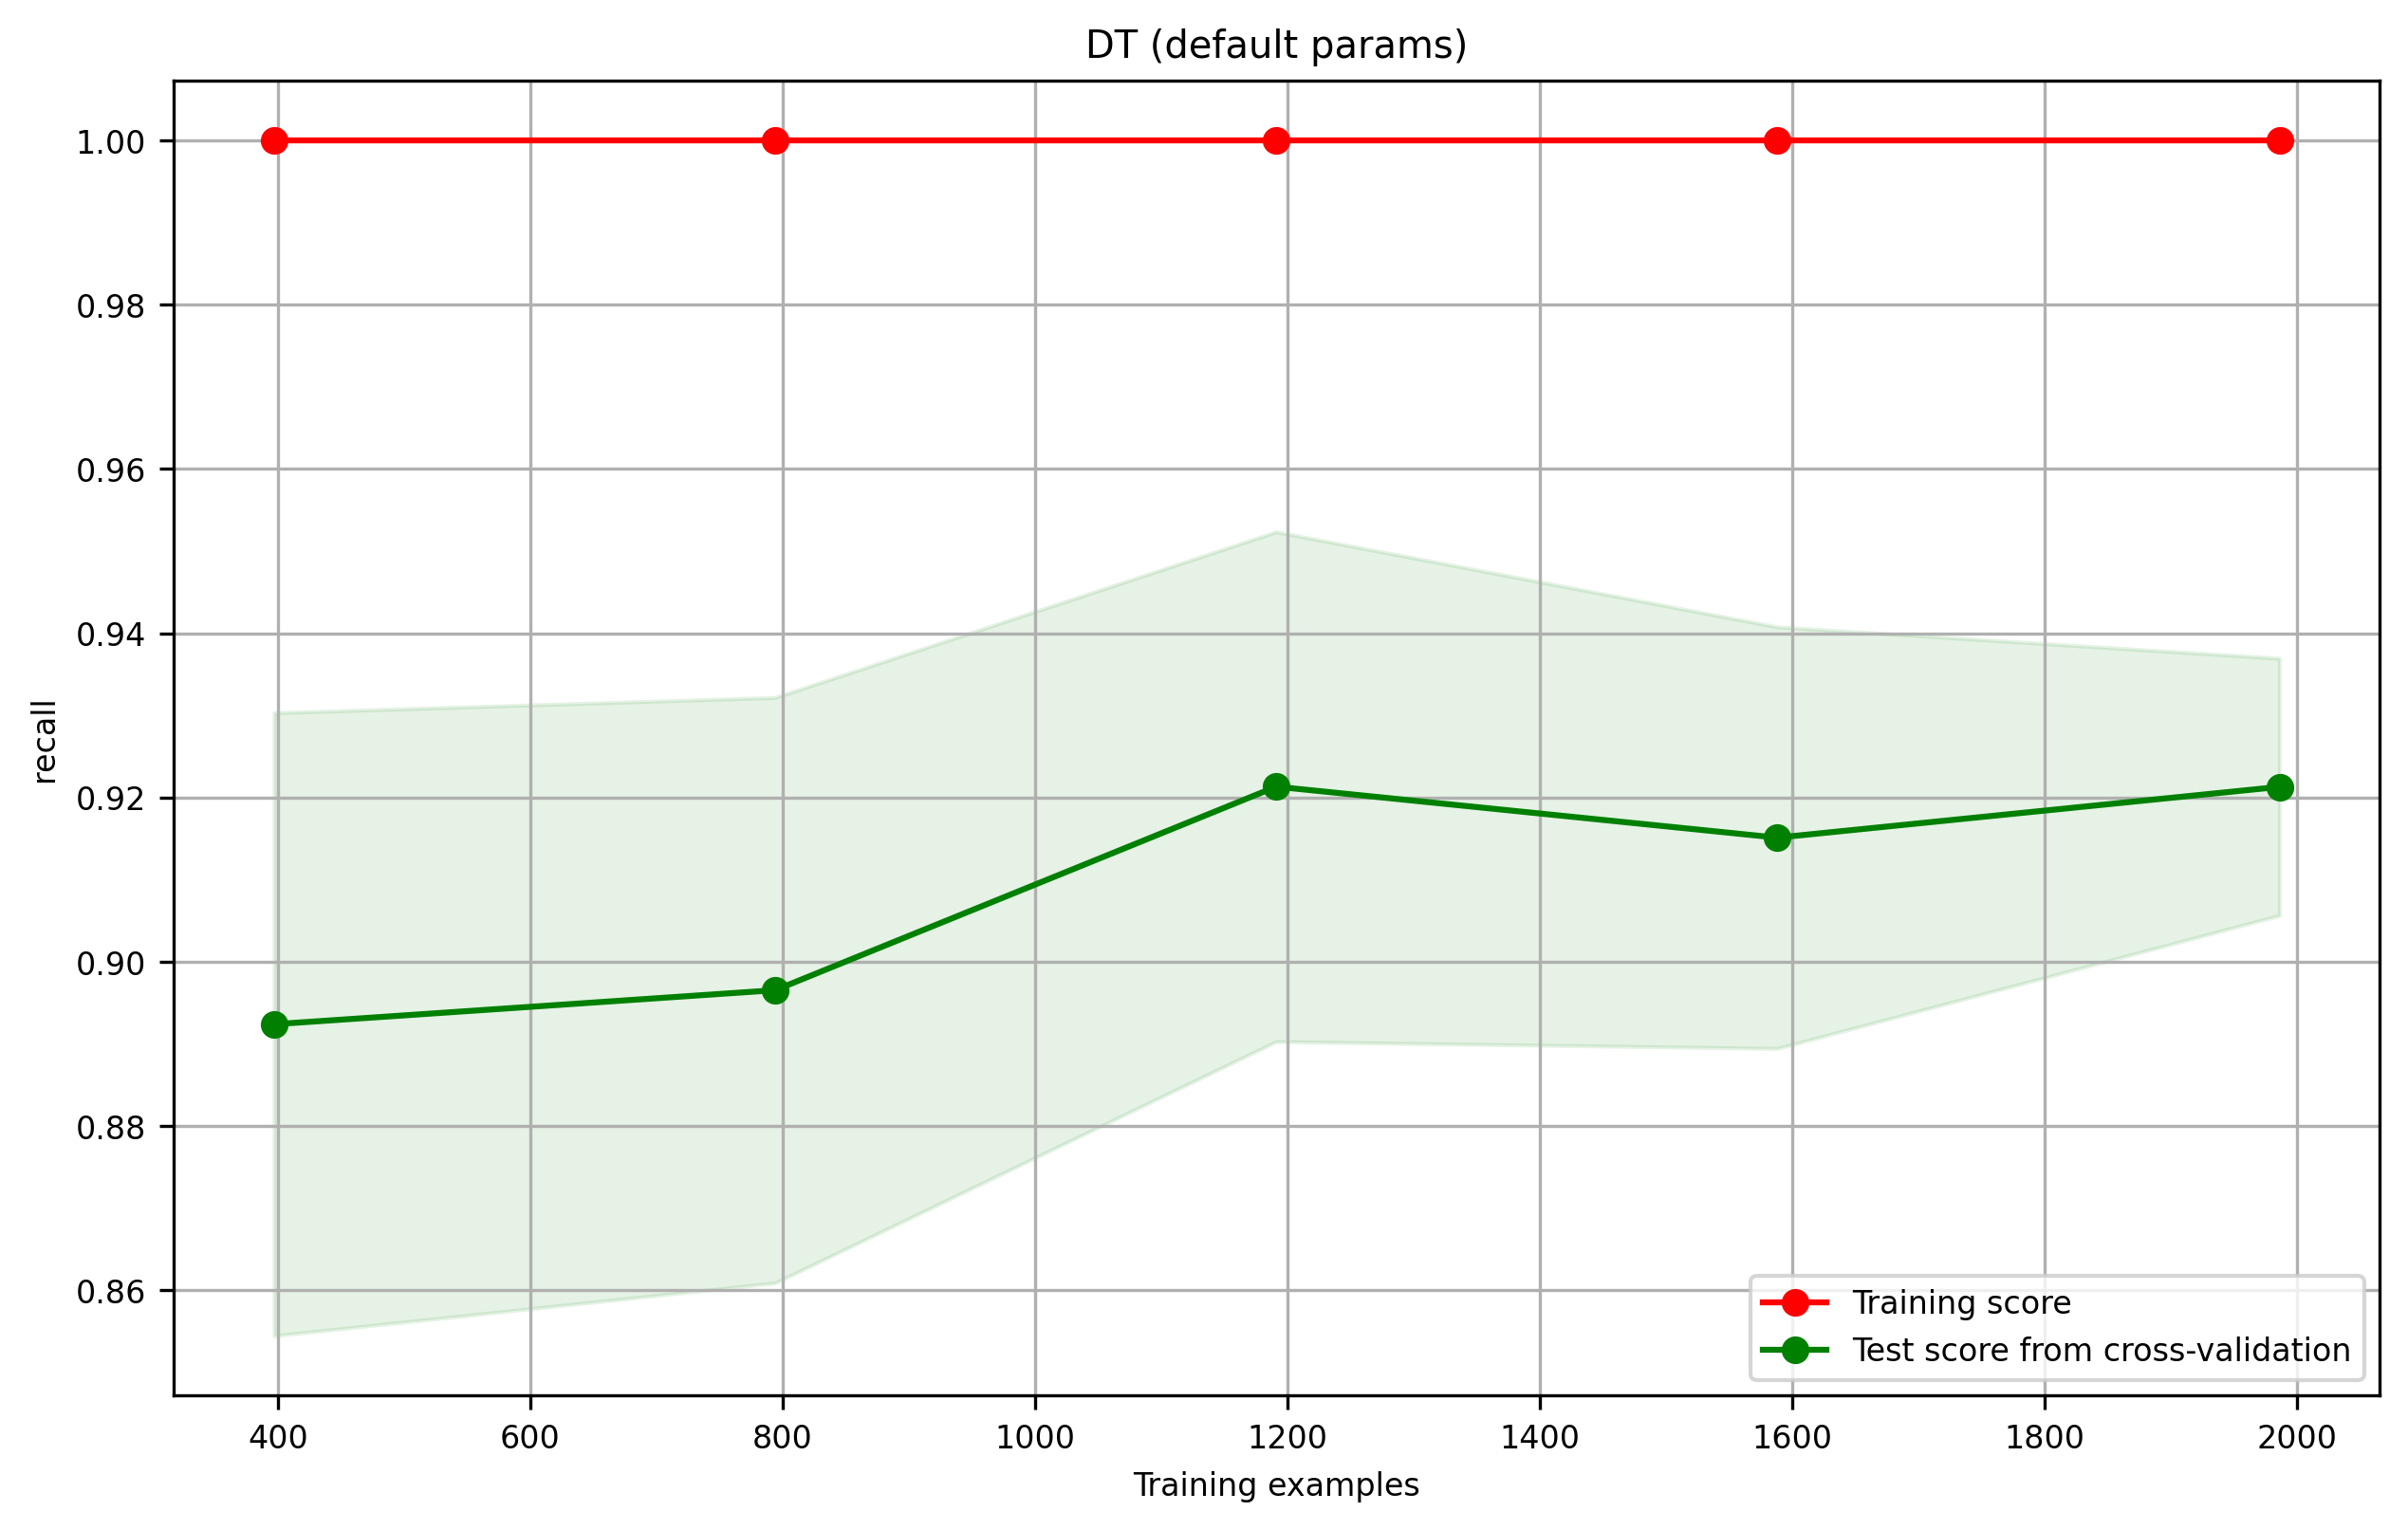

In [437]:
model = DecisionTreeClassifier(random_state = 5)
plot_learning_curve(model, 'DT (default params)', X, y,  cv = cv3, scoring = 'recall');

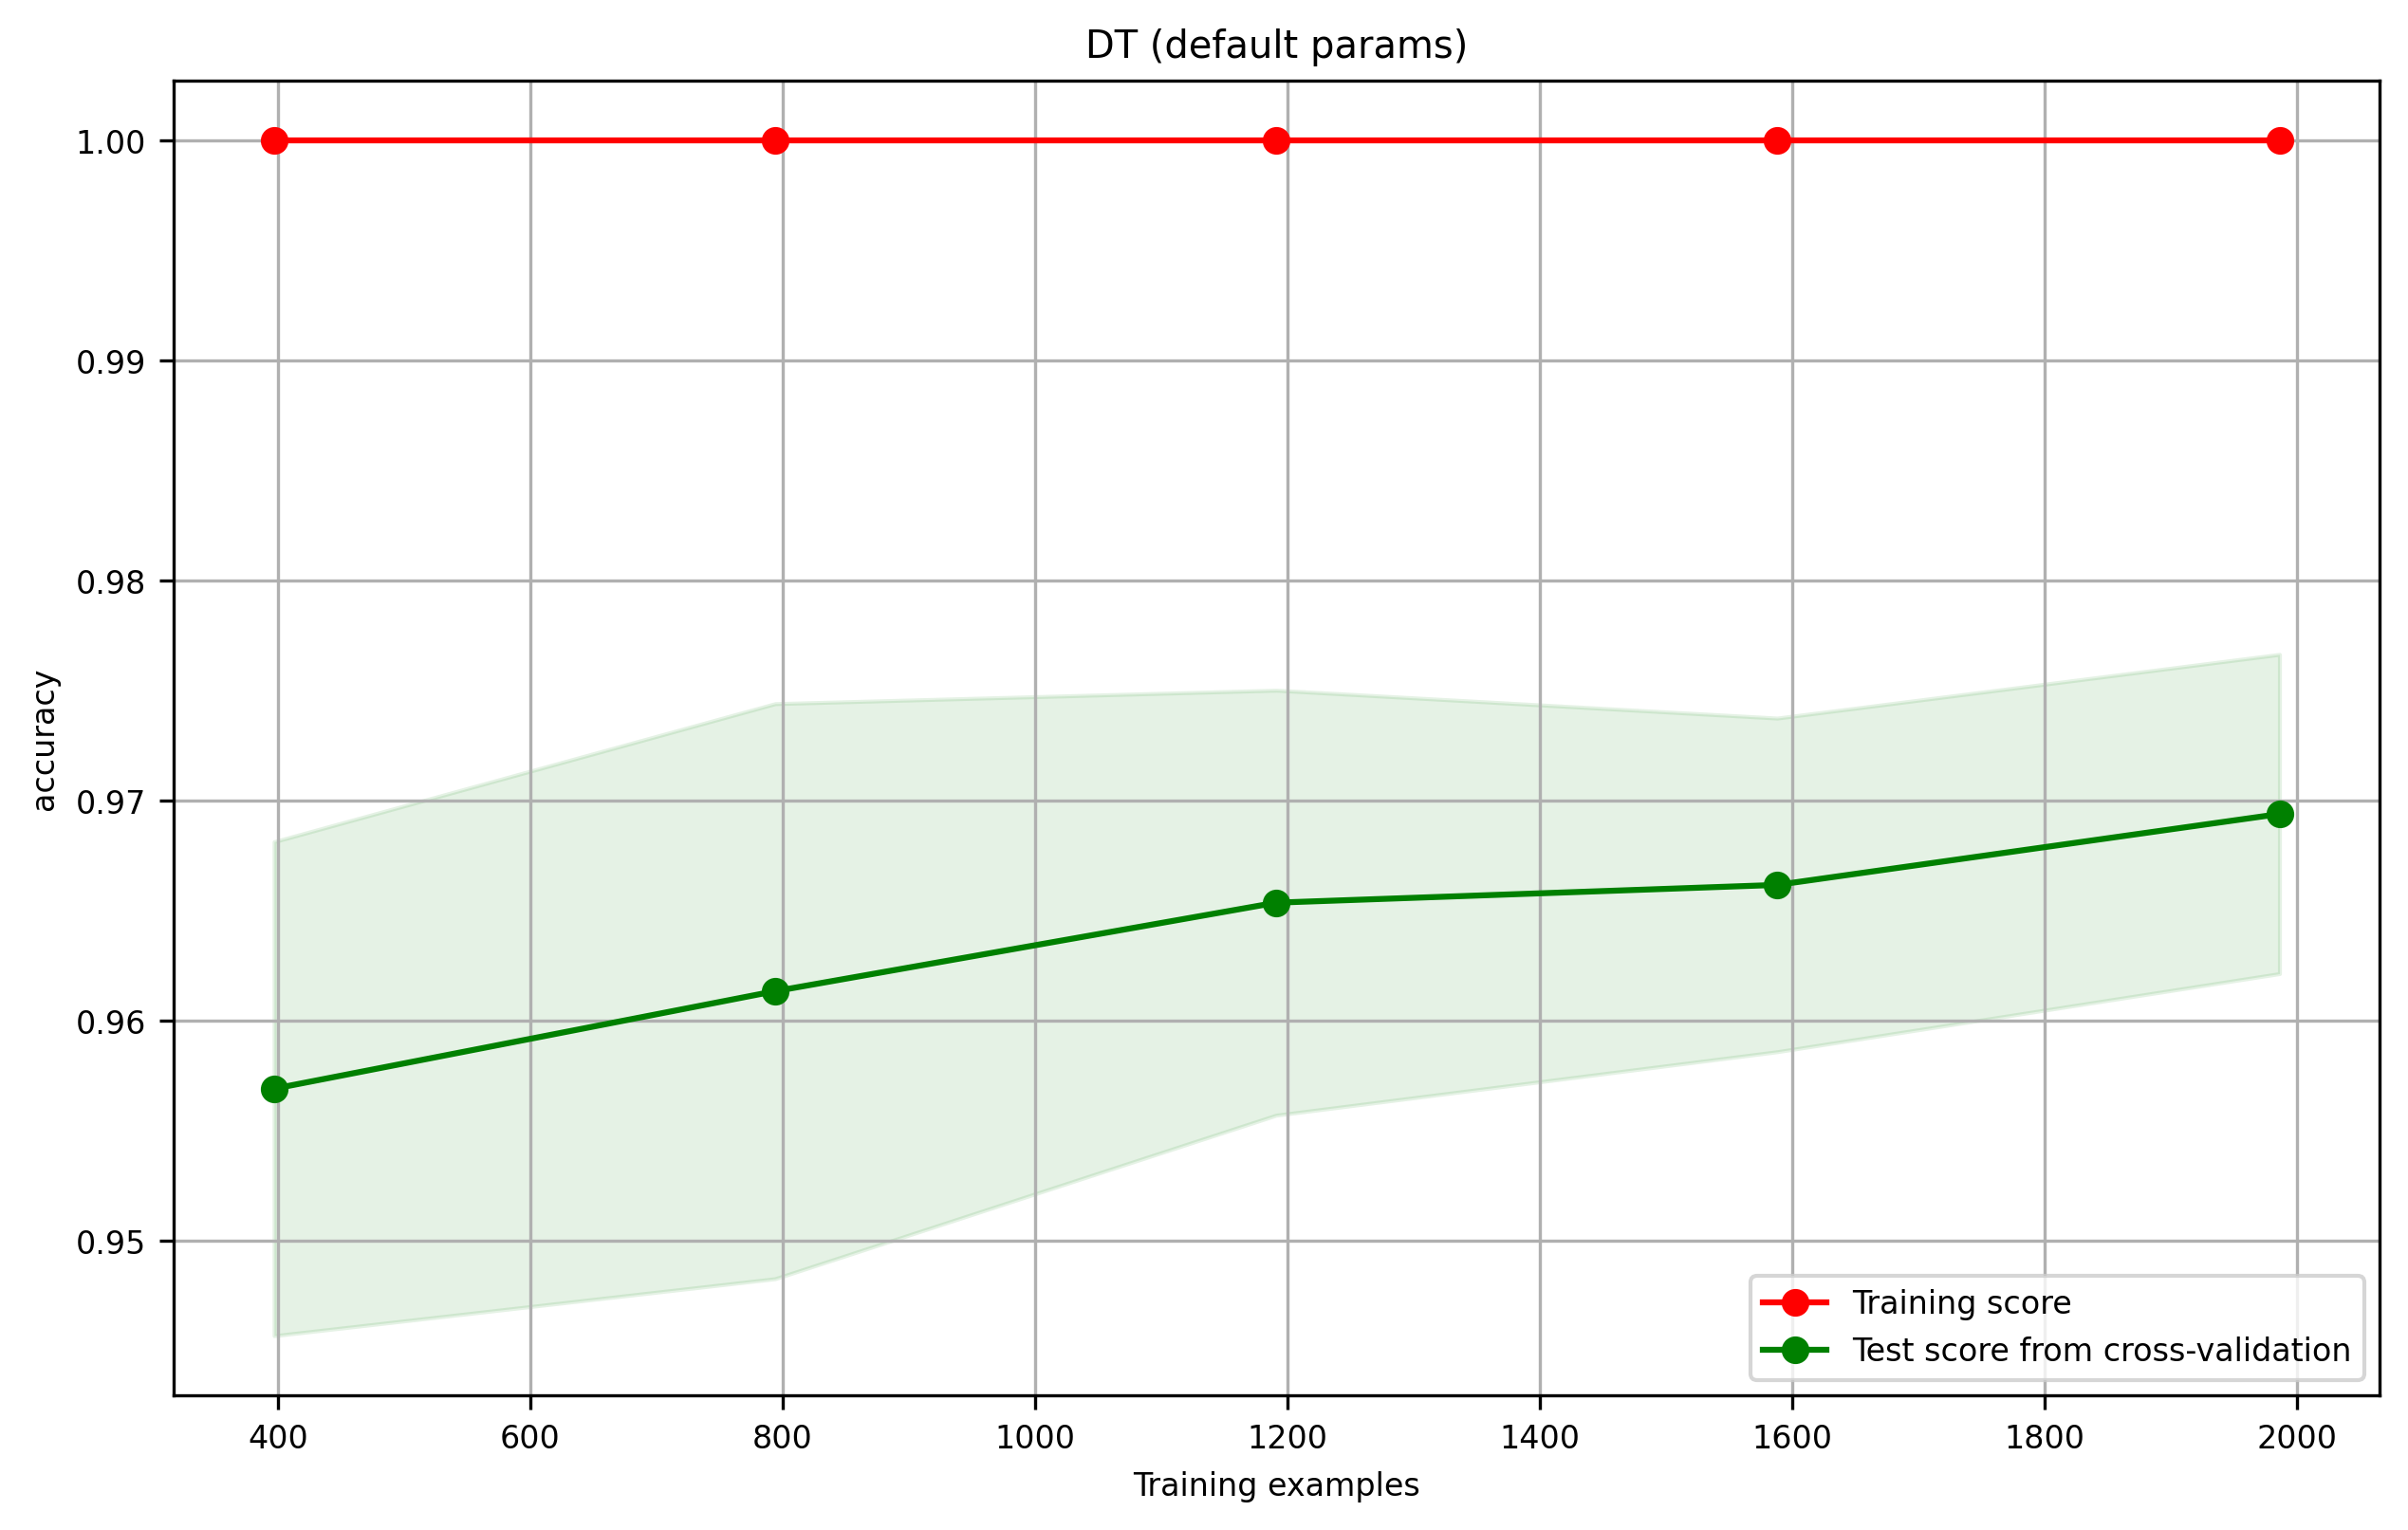

In [439]:
plot_learning_curve(model, 'DT (default params)', X, y,  cv = cv3, scoring = 'accuracy');

El modelo de árbol sobreajusta y es complejo, hay que controlar la profundidad

### **Preguntas**

Responda brevemente:

1. ¿Existe una brecha entre la curva de entrenamiento y la de validación? ¿Qué sugiere eso?

Como se puede ver arriba, para los dos gráficos si existe una brecha. Para el training score tanto la fracción de accuracy y recall son 1.0, es decir, de un 100% para el modelo resultante de un decision tree clasifier con un random state de 5. Se logró en un 100% la clasificación correcta (accuracy) y también se tiene un 100% de completitud (recall). Mientras que para la línea test score a partir del cross validation, para el accuracy resulta ser un poco más "derecho" que para el recall, variando la fracción del mismo concepto. Para el recall hay fracciones desde aproximadamente 0.895 hasta un poco más que 0.92, mientras que para el accuracy hay desde aprox. 0.9585 hasta casi 0.97. Aquello sugiere un sobreajuste y high-variance al entrenar bien los datos pero hay datos que se generalizan sin necesariamente estar presentes como tal.

2. ¿El rendimiento de validación mejora al agregar más ejemplos? El agregar más data con features idénticos y distribución al data en el que se está trabajando, el rendimiento mejorará hasta alcanzar su límite permitido o máximo, o de manera que los datos tengan suficiente varianza para maximizar toda la información a partir de las características otorgadas. Pero luego de que alcanza el límite no es útil, porque el modelo de árbol empieza a sobreajustar y es complejo, por ello se tiene que controlar la profundidad de toda la estructura.
3. ¿Hablaría aquí de alto sesgo, alta varianza o sobreajuste moderado? Justifique. Una alta varianza y sobreajuste moderado, puesto que el sistema fue maximizado, como se mencionó anteriormente.
4. Escriba una conclusión general sobre el comportamiento del árbol base a partir de estas curvas. Para el DT hay un problema de muy alta varianza. Basándose en el cross-validation process se muestra un "gap" entre los train y test scores, cuando se plotean los test scores, para distinto tamaño de set de aprendizaje donde se puede evaluar la varianza y bias y determinar cuál data es más útil, aquello se da a conocer a través de curvas slope-y o una plana (brecha mencionada).


<h2 style="color:fuchsia; font-family:; text-align:center;font-size:20px">
  ❁۪ ｡˚ Desafío: ¿un árbol más simple generaliza mejor? ❁۪ ｡˚
</h2>

Para ver si un árbol más simple generaliza mejor se entrena un segundo árbol, más restringido que el árbol base. Por ejemplo, probando con:

- `max_depth=3`, o
- `min_samples_leaf=10`

Luego se compara su rendimiento con el árbol base usando:
- accuracy
- precision
- recall
- F1-score

In [440]:
#estableciendo los features y targets
features2= np.loadtxt("RRLyrae_features_small.txt", delimiter=',')
targets2= np.loadtxt("RRLyrae_labels_small.txt", delimiter=',')

In [441]:
columnas = ["u-g", "g-r", "r-i", "i-z"]
df2 = pd.DataFrame(features2, columns=columnas)
df2["RR_Lyrae"] = targets2.astype(int)
df2.head()

,u-g,g-r,r-i,i-z,RR_Lyrae
0,0.311,0.714,0.093,0.204,0
1,0.332,0.965,0.122,0.032,0
2,0.394,1.019,0.147,0.096,0
3,0.285,0.865,0.120,0.039,0
4,0.386,0.977,0.181,0.080,0


In [442]:
X = df2[["u-g", "g-r", "r-i", "i-z"]]
y = df2["RR_Lyrae"]

In [443]:
#complete la celda
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=42)

In [444]:
model_tree_new = DecisionTreeClassifier(max_depth=3,random_state=42)
model_tree_new.fit(X_train, y_train)
#entrene el modelo y genere las predicciones
y_pred=model_tree_new.predict(X_test)

In [445]:
df.RR_Lyrae.value_counts()
#Aquí cuerpos no RR Lyrae (0) son 2000 y los que sí son RR Lyrae (1) son 483

RR_Lyrae
0    2000
1     483
Name: count, dtype: int64

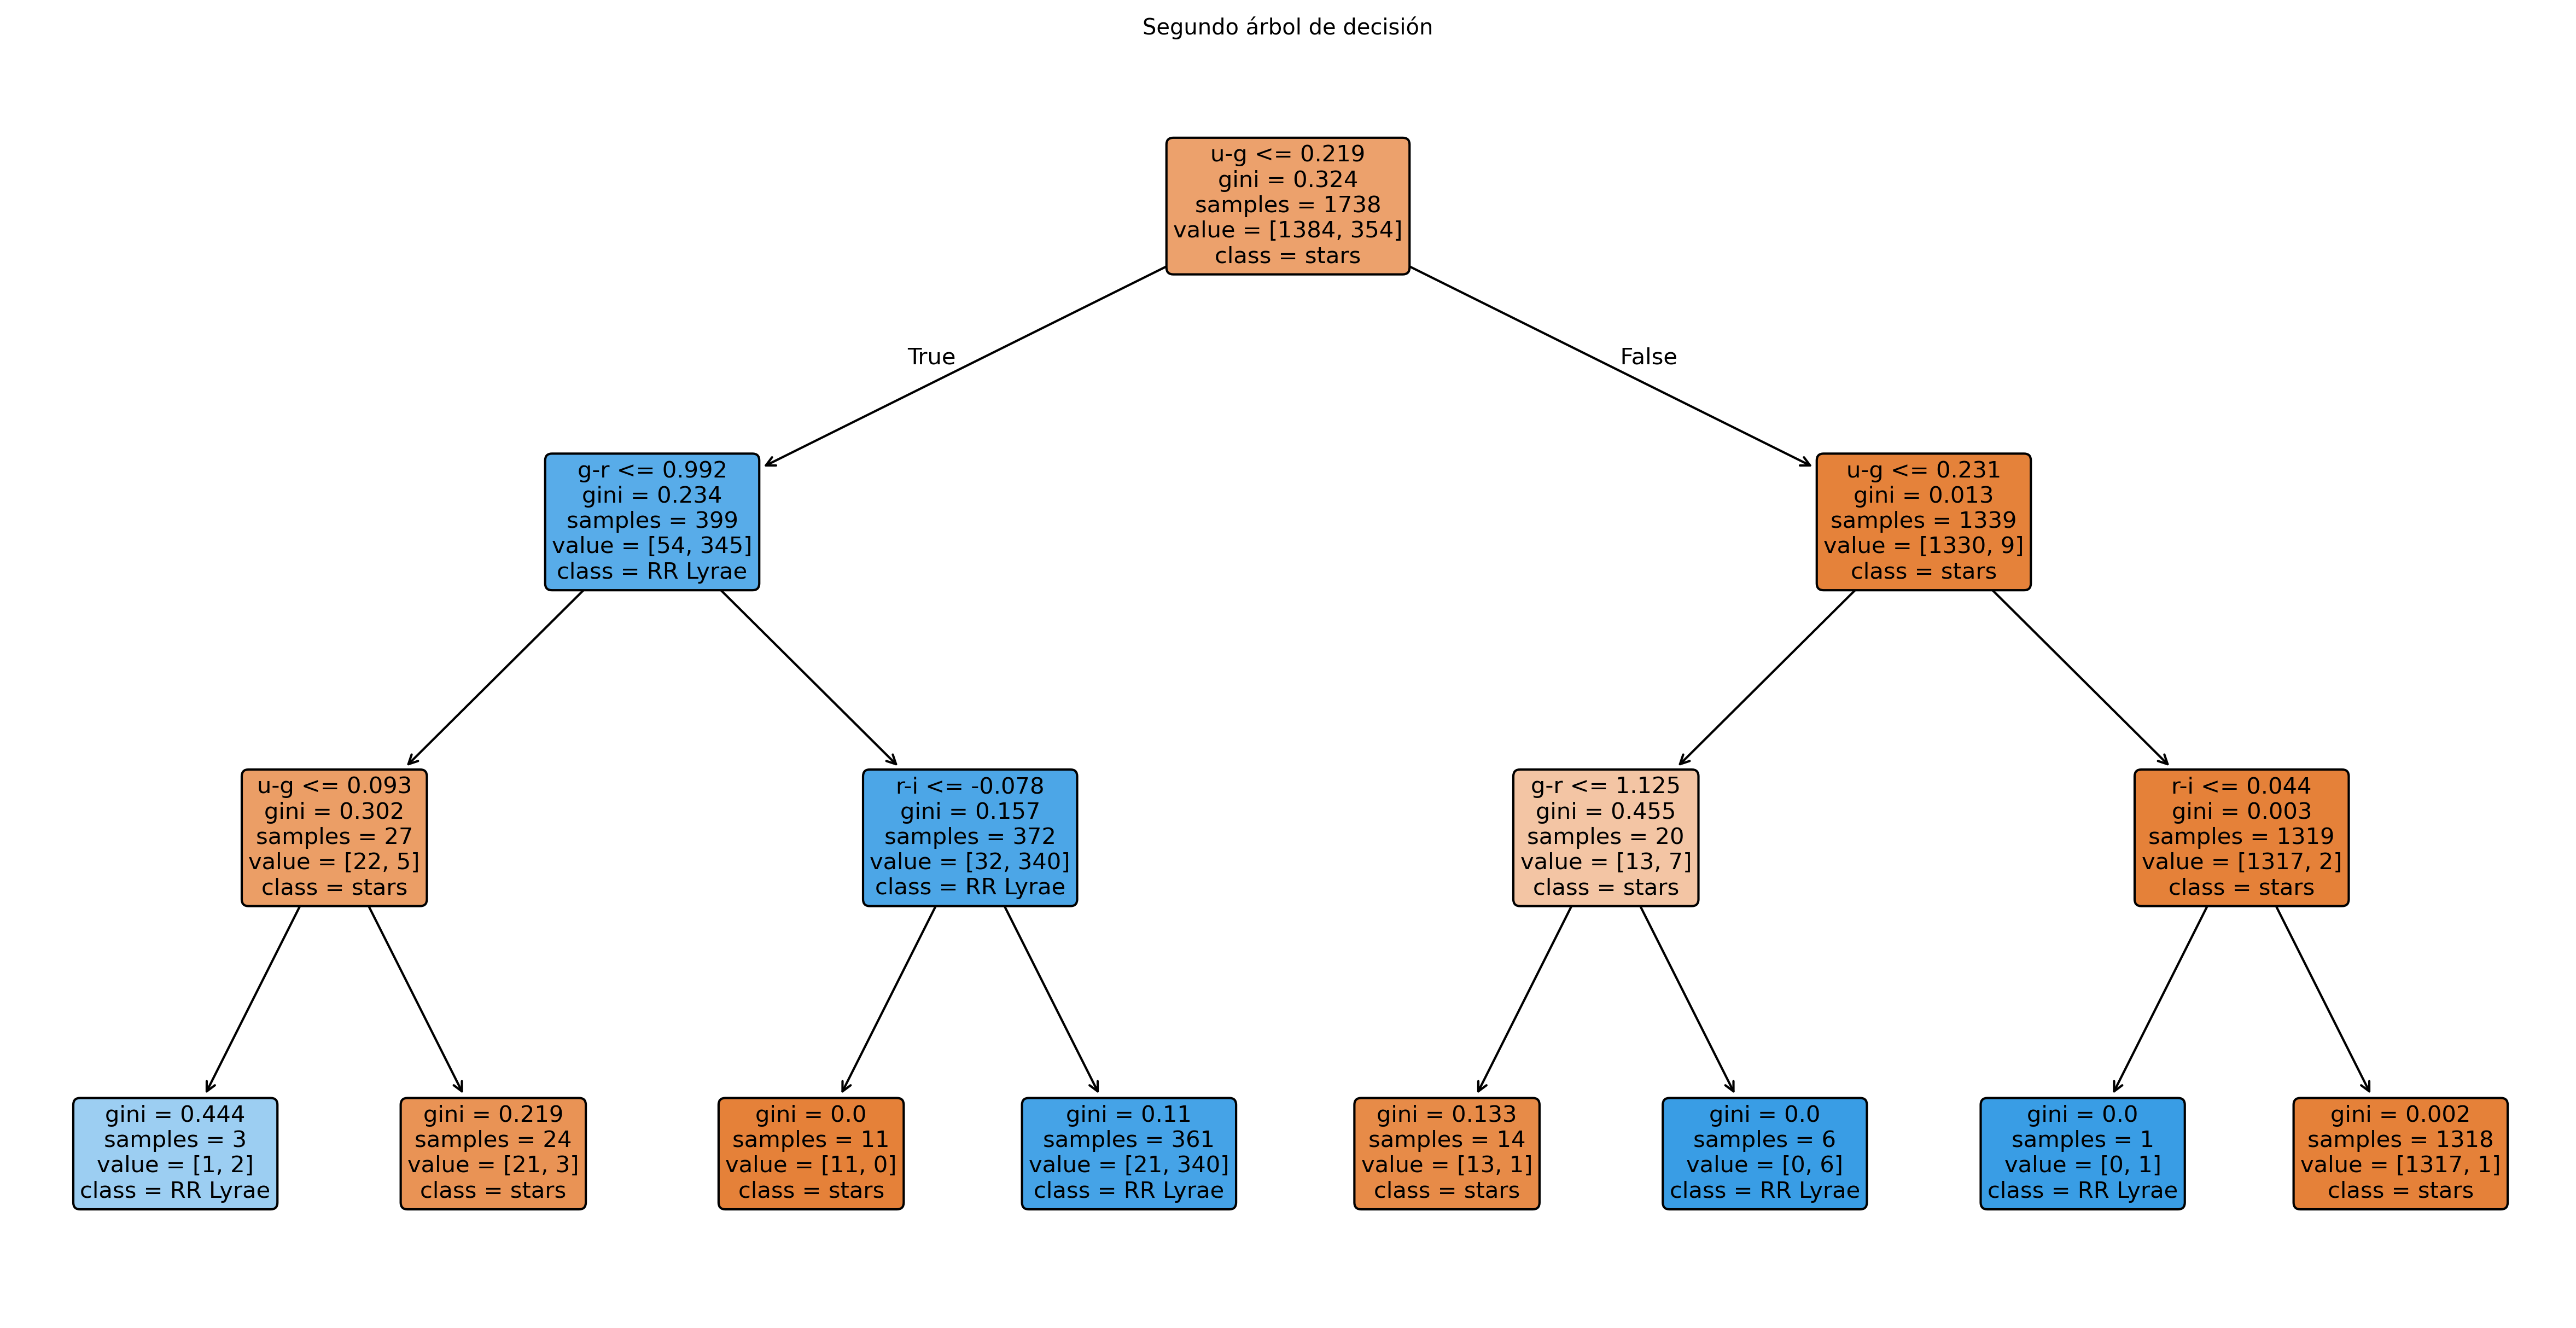

In [446]:
plt.figure(figsize=(20,10))

plot_tree(
    model_tree_new,
    feature_names=X.columns,
    class_names=["stars", "RR Lyrae"],
    filled=True,
    rounded=True,
    #max_depth=3,
    fontsize=10
)
plt.title("Segundo árbol de decisión")
plt.show()

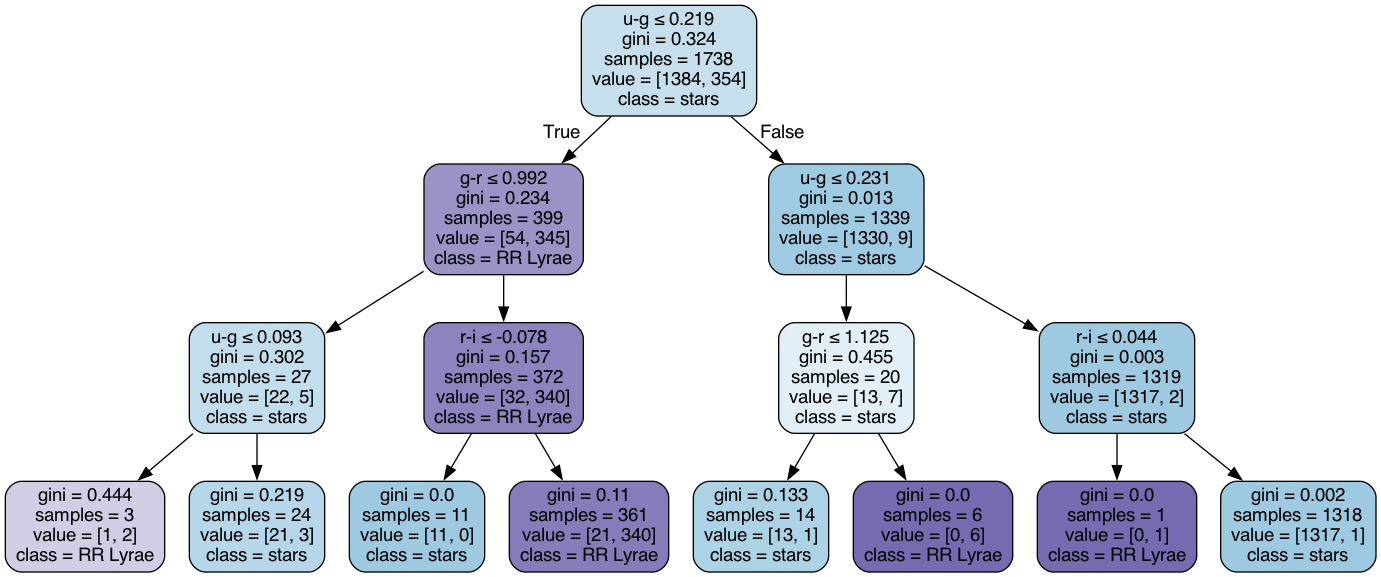

In [447]:
# Recordatorio: Las características siempre se permutan aleatoriamente en cada división.
# Por lo tanto, la mejor división encontrada puede variar, incluso con los mismos datos
# de entrenamiento y max_features=n_features, si la mejora del criterio es idéntica
# para varias divisiones enumeradas durante la búsqueda de la mejor división.
# Para obtener un comportamiento determinista durante el ajuste, random_state debe estar fijo.
#árbol está sobreajustando
dot_data = StringIO()
export_graphviz(
    model_tree_new,
    out_file=dot_data,
    feature_names=['u-g', 'g-r', 'r-i', 'i-z'],
    class_names=['stars', 'RR Lyrae'],
    filled=True,
    rounded=True,
    special_characters=True
)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue().replace("\n", ""))
nodes = graph.get_node_list()
for node in nodes:
    if node.get_label() and 'value = [' in node.get_label():

        values = [float(ii) for ii in node.get_label().split('value = [')[1].split(']')[0].split(',')]
        values = [int(255 * v / sum(values)) for v in values]

        if values[0] > values[1]:
            alpha = int(values[0] - values[1])
            alpha = '{:02x}'.format(alpha)
            color = '#9ecae1' + str(alpha)   # turquesa
        else:
            alpha = int(values[1] - values[0])
            alpha = '{:02x}'.format(alpha)
            color = '#756bb1' + str(alpha)   # magenta

        node.set_fillcolor(color)

Image(graph.create_png())

Como se observa, el modelo de árbol simple con menos profundidad es mucho más entendible

In [449]:
#métricas accuracy del set de entrenamiento y prueba 
print(metrics.accuracy_score(y_train, model_tree_new.predict(X_train))) #train score
print(metrics.accuracy_score(y_test, model_tree_new.predict(X_test))) #test score
print("Precision:", metrics.precision_score(y_test, y_pred))
print("Recall   :", metrics.recall_score(y_test, y_pred))
print("F1-score :", metrics.f1_score(y_test, y_pred))

0.9844649021864211
0.9731543624161074
Precision: 0.9037037037037037
Recall   : 0.9457364341085271
F1-score : 0.9242424242424242


In [450]:
#Matriz de confusión
cm2 = confusion_matrix(y_test, y_pred)
cm2

array([[603,  13],
       [  7, 122]])

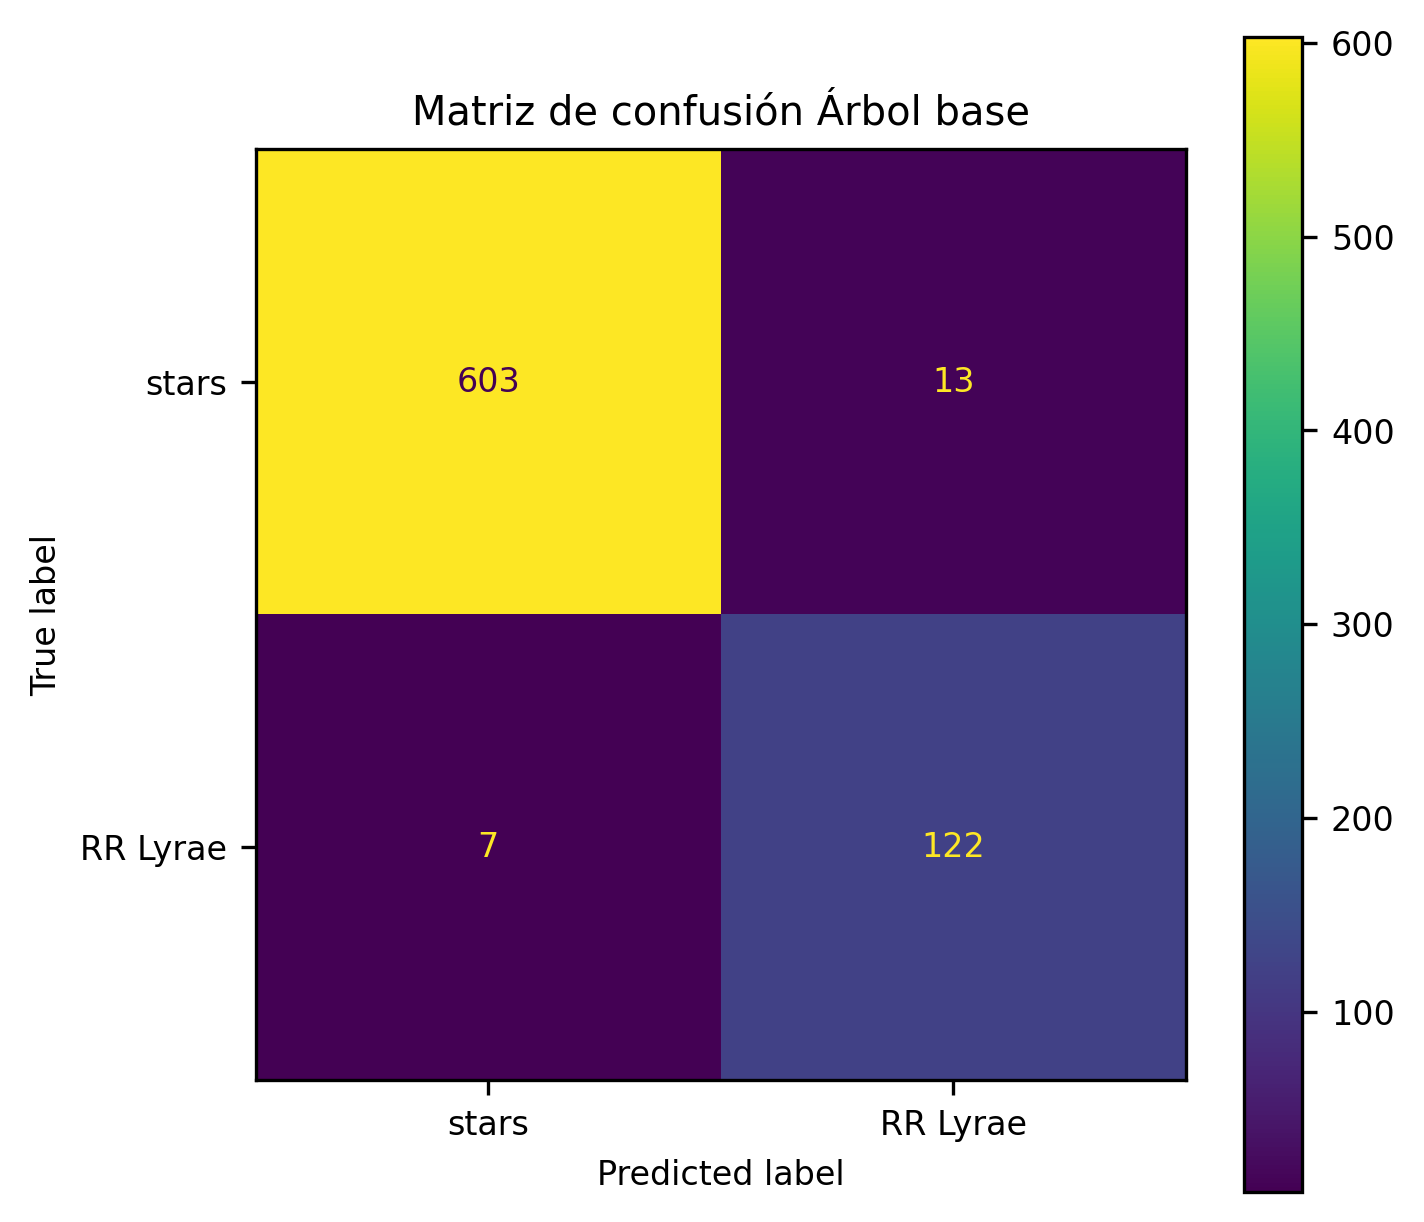

In [451]:
fig, ax = plt.subplots(figsize=(5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=["stars", "RR Lyrae"])
disp.plot(cmap="viridis", ax=ax, colorbar=True)
plt.title("Matriz de confusión Árbol base")
plt.show()

#### A partir de la matriz de confusión obtenida para el segundo árbol:
1.  Identifique los valores de:
   - verdaderos positivos (TP), estos son 603 (stars-stars)
   - verdaderos negativos (TN), estos son 122 (RR Lyrae-RR Lyrae)
   - falsos positivos (FP), estos son 7 (RR Lyrae-stars)
   - falsos negativos (FN), estos son 13 
2. Calcule las métricas "a mano"
Para las métricas:
- Precisión (Pureza) = TP/TP+FP = 603/603+7 = 0.9885
- Recall (Completitud) = TP/TP+FN = 603/603+13 = 0.9788
- F1 Score = (2*0.9885*0.9788)/(0.9885+0.9788) = 0.9836
- Curva ROC y AUC:
  - para la tasa de verdaderos positivos TPR = recall = TP/TP+FN = 0.9788
  - para FPR = FP/TP+TN = 7/603+122 = 0.00965
  - Para este caso se puede decir que la métrica se acerca a un clasificador más casi perfecto que el árbol base, puesto que teniendo en cuenta la gráfica TPR (eje y) y FPR (eje x) mientras TPR más se acerque a 1 mejor es y para FPR mientras más se acerque a 0, resulta ser mejor.

In [452]:
cv1 = KFold(n_splits = 5)
cv2 = KFold(shuffle = True, n_splits = 5, random_state=5)  
cv3 = StratifiedKFold(shuffle = True, n_splits = 5, random_state=5)

In [453]:
cv1.split(X, y)

<generator object _BaseKFold.split at 0x169153890>

In [454]:
for train, test in cv1.split(X, y):
    print('train -  {}   |   test -  {}'.format(
    np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1503  483]   |   test -  [497]
train -  [1503  483]   |   test -  [497]
train -  [1503  483]   |   test -  [497]
train -  [1504  483]   |   test -  [496]
train -  [1987]   |   test -  [ 13 483]


In [455]:
for train, test in cv2.split(X, y):
    print('train -  {}   |   test -  {}'.format(
    np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1600  386]   |   test -  [400  97]
train -  [1610  376]   |   test -  [390 107]
train -  [1587  399]   |   test -  [413  84]
train -  [1599  388]   |   test -  [401  95]
train -  [1604  383]   |   test -  [396 100]


In [456]:
for train, test in cv3.split(X, y):
    print('train -  {}   |   test -  {}'.format(
    np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1600  386]   |   test -  [400  97]
train -  [1600  386]   |   test -  [400  97]
train -  [1600  386]   |   test -  [400  97]
train -  [1600  387]   |   test -  [400  96]
train -  [1600  387]   |   test -  [400  96]


In [457]:
scores1 = cross_validate(DecisionTreeClassifier(max_depth=3), X, y, cv=cv1, scoring='accuracy')

scores2 = cross_validate(DecisionTreeClassifier(max_depth=3), X, y, cv=cv2, scoring='accuracy')

scores3 = cross_validate(DecisionTreeClassifier(max_depth=3), X, y, cv=cv3, scoring='accuracy')

In [458]:
scores1,scores2,scores3

({'fit_time': array([0.00698328, 0.00372386, 0.00244212, 0.00170207, 0.00068593]),
  'score_time': array([0.00309777, 0.00209188, 0.00095415, 0.00077987, 0.00069404]),
  'test_score': array([0.98189135, 0.9778672 , 0.97183099, 0.97580645, 0.02620968])},
 {'fit_time': array([0.00154066, 0.00194097, 0.00161672, 0.00149488, 0.00150704]),
  'score_time': array([0.00073123, 0.00083518, 0.00068116, 0.00069404, 0.0006671 ]),
  'test_score': array([0.97987928, 0.97585513, 0.98189135, 0.96975806, 0.96975806])},
 {'fit_time': array([0.00143504, 0.00146508, 0.00153399, 0.00149894, 0.00143194]),
  'score_time': array([0.00065398, 0.00068188, 0.00070977, 0.00067091, 0.00066996]),
  'test_score': array([0.98993964, 0.97183099, 0.97183099, 0.98185484, 0.96975806])})

In [459]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['test_score'].std()))
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['test_score'].std()))
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['test_score'].std()))

0.787 0.380
0.975 0.005
0.977 0.008


In [460]:
scores1 = cross_validate(DecisionTreeClassifier(max_depth=3,random_state=1), X,y, cv = cv1, scoring = 'recall')
scores2 = cross_validate(DecisionTreeClassifier(max_depth=3,random_state=1), X,y, cv = cv2, scoring = 'recall')
scores3 = cross_validate(DecisionTreeClassifier(max_depth=3,random_state=1), X,y, cv = cv3, scoring = 'recall')

/opt/homebrew/Caskroom/miniforge/base/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Caskroom/miniforge/base/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Caskroom/miniforge/base/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt

In [461]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['test_score'].std()))
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['test_score'].std()))
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['test_score'].std()))

nan nan
0.961 0.013
0.961 0.024


In [462]:
scores1 = cross_validate(DecisionTreeClassifier(max_depth=3), X,y, cv = cv1, scoring = 'recall', \
                         return_train_score = True)

scores2 = cross_validate(DecisionTreeClassifier(max_depth=3), X,y, cv = cv2, scoring = 'recall', \
                         return_train_score = True)

scores3 = cross_validate(DecisionTreeClassifier(max_depth=3), X,y, cv = cv3, scoring = 'recall',
                         return_train_score = True)
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['train_score'].mean()))
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['train_score'].mean()))
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['train_score'].mean()))

nan nan
0.961 0.979
0.963 0.973


/opt/homebrew/Caskroom/miniforge/base/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Caskroom/miniforge/base/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Caskroom/miniforge/base/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt

In [463]:
model1 = DecisionTreeClassifier(max_depth=3,random_state = 3)
y_cv3 = cross_val_predict(model1, X,y, cv = cv3)
# Estas son las predicciones,
# y son independientes del parámetro de evaluación

In [464]:
metrics.confusion_matrix(targets,y_cv3)

array([[1961,   39],
       [  18,  465]])

In [465]:
model2 = DecisionTreeClassifier(max_depth=3,random_state = 3)
y_cv2 = cross_val_predict(model2, X,y, cv = cv2)
np.sum(y_cv3-y_cv2)
np.sum(y_cv2)
np.sum(y_cv3 != y_cv2) #comparando las predicciones
metrics.confusion_matrix(targets,y_cv2)
metrics.confusion_matrix(targets,y_cv3)

array([[1961,   39],
       [  18,  465]])

In [466]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=5,
                        n_jobs=-1, train_sizes=np.linspace(0.2, 1.0, 5), scoring = 'accuracy'):
    """
    Generate a simple plot of the test and training learning curve.

    Parameters
    ----------
    estimator : object type that implements the "fit" and "predict" methods
        An object of that type which is cloned for each validation.

    title : string
        Title for the chart.

    X : array-like, shape (n_samples, n_features)
        Training vector, where n_samples is the number of samples and
        n_features is the number of features.

    y : array-like, shape (n_samples) or (n_samples, n_features), optional
        Target relative to X for classification or regression;
        None for unsupervised learning.

    ylim : tuple, shape (ymin, ymax), optional
        Defines minimum and maximum yvalues plotted.

    cv : int, cross-validation generator or an iterable, optional
        Determines the cross-validation splitting strategy.
        Possible inputs for cv are:
          - None, to use the default 3-fold cross-validation,
          - integer, to specify the number of folds.
          - :term:`CV splitter`,
          - An iterable yielding (train, test) splits as arrays of indices.

        For integer/None inputs, if ``y`` is binary or multiclass,
        :class:`StratifiedKFold` used. If the estimator is not a classifier
        or if ``y`` is neither binary nor multiclass, :class:`KFold` is used.

        Refer :ref:`User Guide <cross_validation>` for the various
        cross-validators that can be used here.

    n_jobs : int or None, optional (default=None)
        Number of jobs to run in parallel.
        ``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.
        ``-1`` means using all processors. See :term:`Glossary <n_jobs>`
        for more details.

    train_sizes : array-like, shape (n_ticks,), dtype float or int
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve. If the dtype is float, it is regarded as a
        fraction of the maximum size of the training set (that is determined
        by the selected validation method), i.e. it has to be within (0, 1].
        Otherwise it is interpreted as absolute sizes of the training sets.
        Note that for classification the number of samples usually have to
        be big enough to contain at least one sample from each class.
        (default: np.linspace(0.1, 1.0, 5))
    """
    plt.figure(figsize=(10,6))
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel(str(scoring))

    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring = scoring, shuffle=True, random_state=42)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Test score from cross-validation")

    plt.legend(loc="best")
    return plt

In [467]:
model = DecisionTreeClassifier(max_depth=3,random_state = 5)

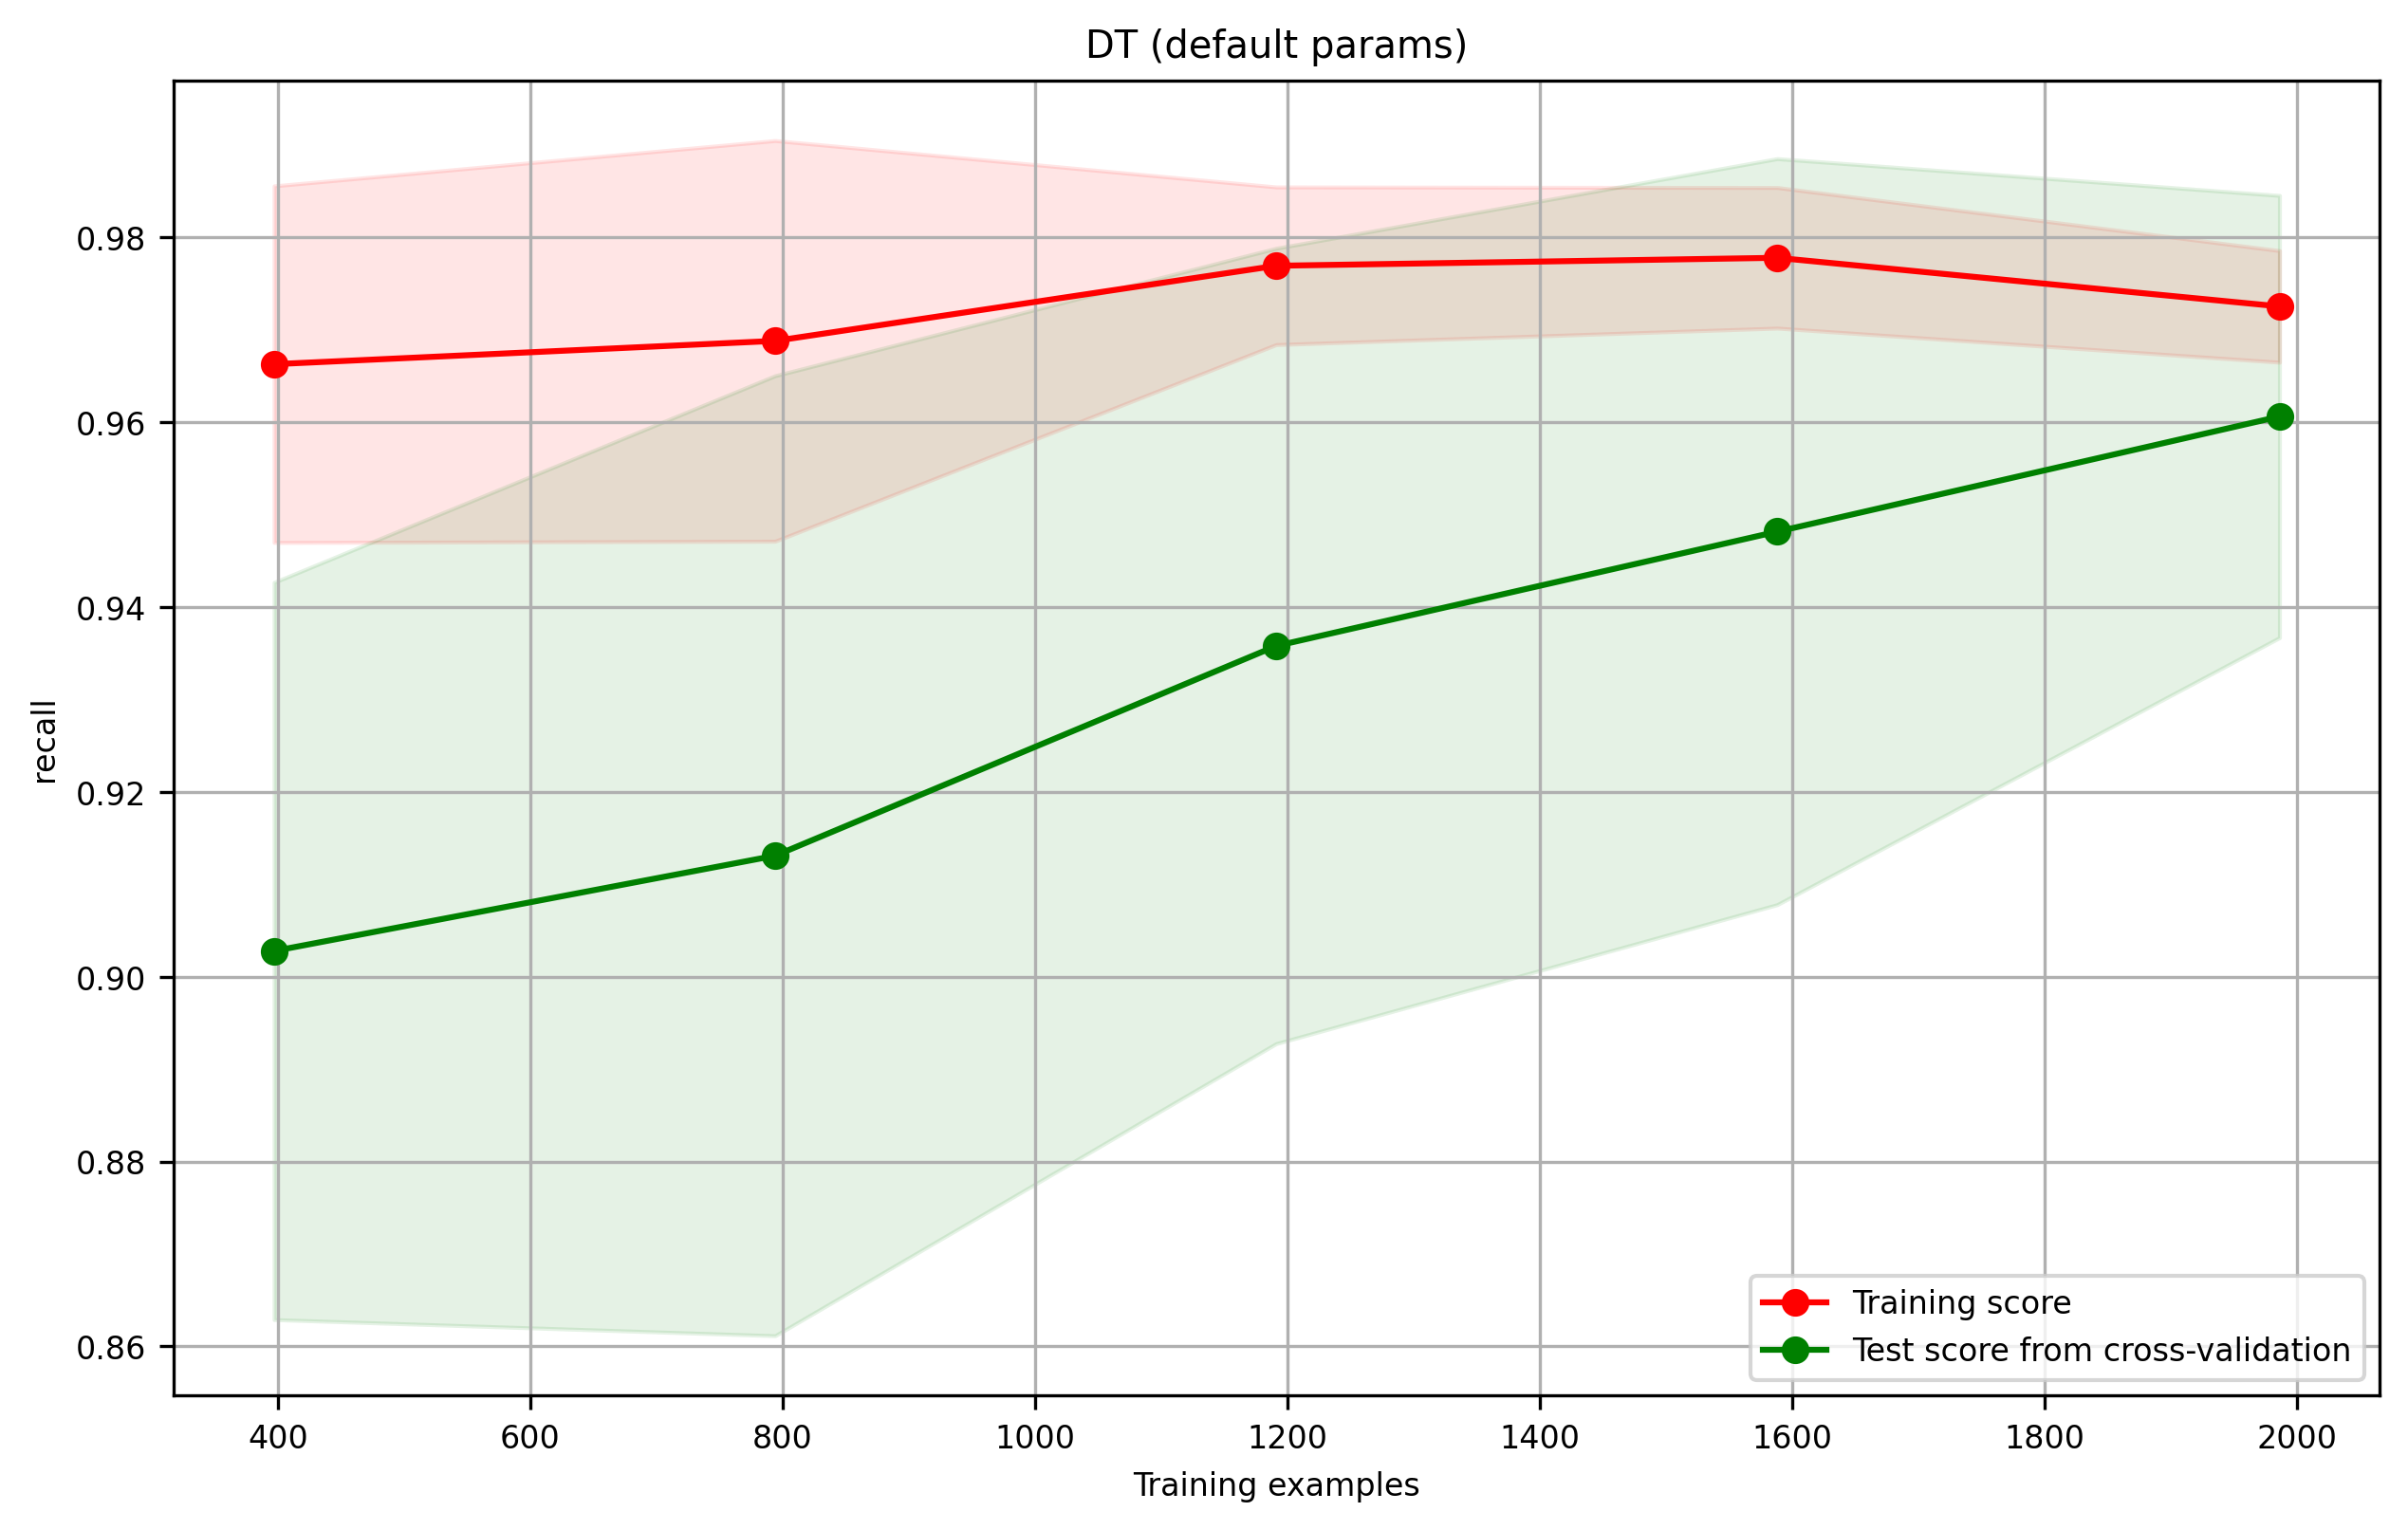

In [468]:
plot_learning_curve(model, 'DT (default params)', X, y,  cv = cv3, scoring = 'recall');

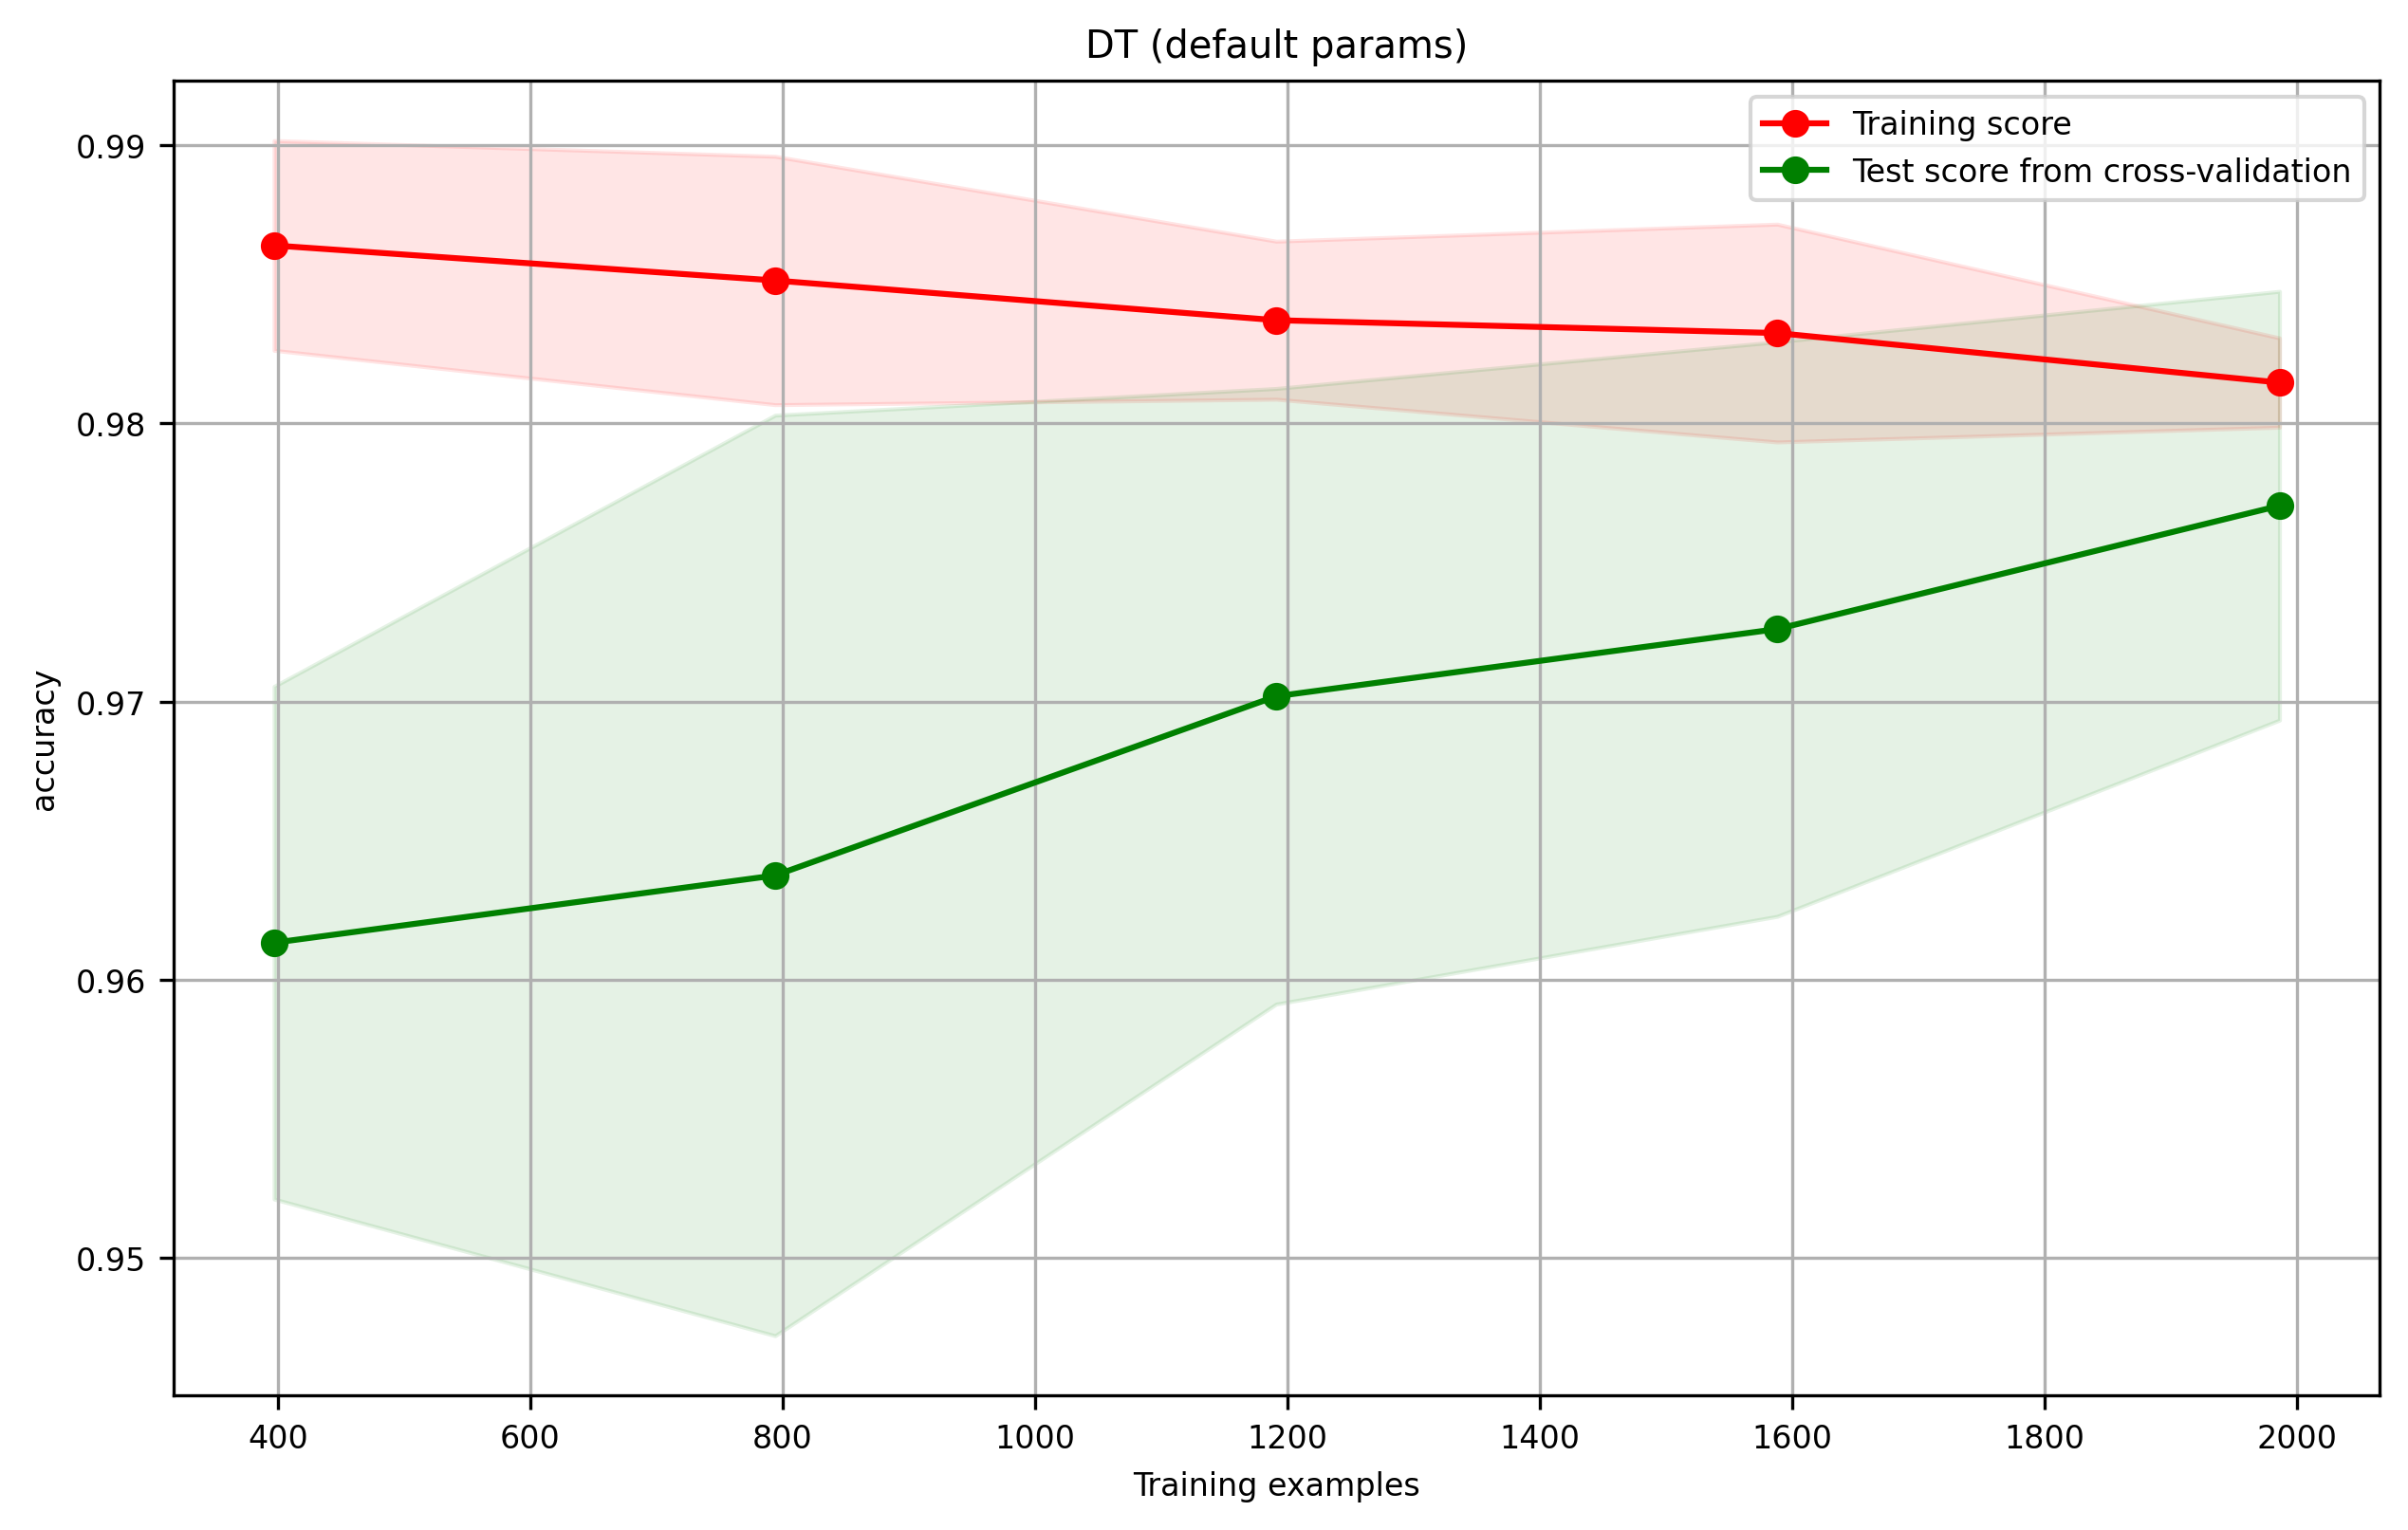

In [469]:
plot_learning_curve(model, 'DT (default params)', X, y,  cv = cv3, scoring = 'accuracy');

### Preguntas

A partir de los resultados obtenidos con validación cruzada:

1. ¿Qué ocurrió con el rendimiento al restringir la complejidad del árbol?
   El rendimiento tanto para el recall y accuracy con el árbol restringuido aumentó. Para el recall (relacionado con completitud)los valores son desde un poco más de 0.90 a alrededor de 0.96, mientras que para accuracy es desde un poco más de 0.96 a alrededor de 0.977. Luego, hay mejor rendimiento que para el árbol base.
2. ¿El árbol más simple empeoró o mejoró la generalización? Considerando el árbol más simple, este mejoró la generalización, puesto que el rendimiento fue mejor y no se ve un sobreajuste del todo, como para el caso del árbol base.
3. ¿Qué sugieren estos resultados sobre el árbol base? Que generaliza mal los datos, puesto que hay datos en el train set que no se utilizaron, y eso se muestra en forma de que sobreajusta.
4. En este problema, ¿parece conveniente usar el árbol sin restricciones? No es conveniente, puesto que le da mucha profundidad, luego es fundamental controlarla para que se llegue a un modelo que represente los data set.
5. ¿Qué métrica le parece más importante para decidir entre ambos modelos?  quizás completitud, porque se quieren obtener la mayor cantidad de RR Lyrae (que si sean y que si sean clasificados correctamente)

Comparación de valores de métrica: 
Para el árbol base se obtuvieron valores de métrica para la precisión, recall, F1 score, TPR y FPR. Estos son 0.9884, 0.9724, 0.9803, 0.9724 y 0.0125, respectivamente. Mientras que para el árbol simple se obtuvo 0.9885, 0.9788, 0.9836, 0.9788 y 0.00965, respectivamente. Luego, los valores de las métricas para el árbol simple resultan ser mayores y más precisas que para el árbol base donde se tenía sobreajuste, con mucha profundidad y no estaba controlado como para poder extraer conclusiones que realmente representen el set trabajado.

<h2 style="color:Fuchsia; font-family:; text-align:center;font-size:20px">
  ❁۪ ｡˚ Comparando con k-Nearest Neighbors  ❁۪ ｡˚
</h2>

Hasta ahora se ha trabajado con árboles de decisión. Ahora se compara ese enfoque con un clasificador distinto: **k-Nearest Neighbors (kNN)**.

Aplicando el kNN, que cómo se había visto en actividades anteriores, es un algoritmo distinto, sobre encontrar los vecinos más cercanos, clasificando según las etiquetas de estos mismos, que se pueden denominar "k" nearest neighbors. Donde se calculan las distancias entre "vecinos", por lo que la **escala** de las variables importa totalmente. Además, el método resulta útil para escoger cuál método podría tener más potencial o es más "prometedor" al momento de presentar datos y que permita analizarlos.
Entrene un modelo kNN y compárelo con el árbol simple usando validación cruzada estratificada. Como el kNN está basado en distancias, las variables se tienen que escalar antes de entrenarse.

### Instrucciones

1. Entrene un modelo kNN con `k=5`.
2. Use un `StandardScaler` antes del clasificador.
3. Evalúe el modelo con validación cruzada estratificada usando:
   - accuracy
   - precision
   - recall
   - F1-score
4. Compare sus resultados con los del árbol simple.
5. Luego explore distintos valores de `k` y vea cómo cambian las métricas.

In [470]:
import sklearn
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.pipeline import Pipeline #esto se requiere para hacer ejecutar jerárquicamente/estratificada
from sklearn.preprocessing import StandardScaler
#el paquete de sklearn.preprocessing sirve para poder tanto usar funciones y transformar 
#internamente los elementos y vectores correspondientes a determinado feature "puro" del modelo, 
#así se representa de forma más adecuada para los estimadores

In [471]:
#teniendo el set completo, y los sets de entrenamiento como de prueba
X = df[["u-g", "g-r", "r-i", "i-z"]]
y = df["RR_Lyrae"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [472]:
#aquí busqué a través de la IA una forma que complemente tanto el escalamiento 
#además que el proceso mismo haga al mismo tiempo la búsqueda de los vecinos más cercanos
#para que sea más eficiente el cálculo
knn5 = Pipeline([("scaler", StandardScaler()),("knn", KNeighborsClassifier(n_neighbors=5))])
#el knn5 hace el proceso pipeline como estratificada, osea como jerárquicamente. 
#Primero se realiza el escalamiento y luego la búsqueda de los 5 primeros vecinos más cercanos 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) #aquí la idea es barajar los datos como antes
scores_knn = cross_validate(knn5,X,y,cv=cv,scoring=["accuracy", "precision", "recall", "f1"])
print("Accuracy:", scores_knn["test_accuracy"].mean())
print("Precision:", scores_knn["test_precision"].mean())
print("Recall:", scores_knn["test_recall"].mean())
print("F1-score:", scores_knn["test_f1"].mean())
knn5

Accuracy: 0.9782485233984552
Precision: 0.9255663859949574
Recall: 0.9668599656357388
F1-score: 0.9455895405234426


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('knn', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value d

In [473]:
DT_1 = DecisionTreeClassifier(max_depth=3, random_state=42) #para el arbol simple 
scores_tree = cross_validate(DT_1,X,y,cv=cv,scoring=["accuracy", "precision", "recall", "f1"])
print("Accuracy:", scores_tree["test_accuracy"].mean())
print("Precision:", scores_tree["test_precision"].mean())
print("Recall:", scores_tree["test_recall"].mean())
print("F1-score:", scores_tree["test_f1"].mean())

Accuracy: 0.9738195300837281
Precision: 0.9168786790327118
Recall: 0.9523625429553265
F1-score: 0.9341426558589371


In [474]:
#Aquí se comparan los valores
print("Método                  Accuracy           Precision             Recall         F1-score")
print("DT                    ",
      scores_tree["test_accuracy"].mean(),
      scores_tree["test_precision"].mean(),
      scores_tree["test_recall"].mean(),
      scores_tree["test_f1"].mean())
print("kNN (5 neighbours)    ",
      scores_knn["test_accuracy"].mean(),
      scores_knn["test_precision"].mean(),
      scores_knn["test_recall"].mean(),
      scores_knn["test_f1"].mean())

Método                  Accuracy           Precision             Recall         F1-score
DT                     0.9738195300837281 0.9168786790327118 0.9523625429553265 0.9341426558589371
kNN (5 neighbours)     0.9782485233984552 0.9255663859949574 0.9668599656357388 0.9455895405234426


Comparando el modelo validación cruzada estratificada y comparando los resultados con los del árbol simple, para el kNN con 5 neighbours todas las métricas tienen valores un poco mayor que para el árbol simple. Enfatizando el valor del recall, pues es el más aumento de todas las métricas y además el que se quiere como objetivo, debido a que se está buscando un modelo para encontrar justamente a elementos que sean RR Lyrae como todos los posibles, entonces el kNN resulta ser quizás un mejor modelo para encontrar completitud del set que se entrenó.

In [475]:
#esta parte sirve para poder variar la cantidad de k neighbours desde 1 a 31
#y de manera que los datos se vayan guardando para cada concepto y que sea más eficiente de ejecutar
ks = range(1, 31)
accuracy = []
precision = []
recall = []
f1 = []
#como antes, se considera tanto que la ejecución sea eficiente y también que el scoring funcione para todas las métricas
for k in ks:
    knn = Pipeline([("scaler", StandardScaler()),("knn", KNeighborsClassifier(n_neighbors=k))])
    scores = cross_validate(knn,X,y,cv=cv,scoring=["accuracy", "precision", "recall", "f1"])
    accuracy.append(scores["test_accuracy"].mean())
    precision.append(scores["test_precision"].mean())
    recall.append(scores["test_recall"].mean())
    f1.append(scores["test_f1"].mean())

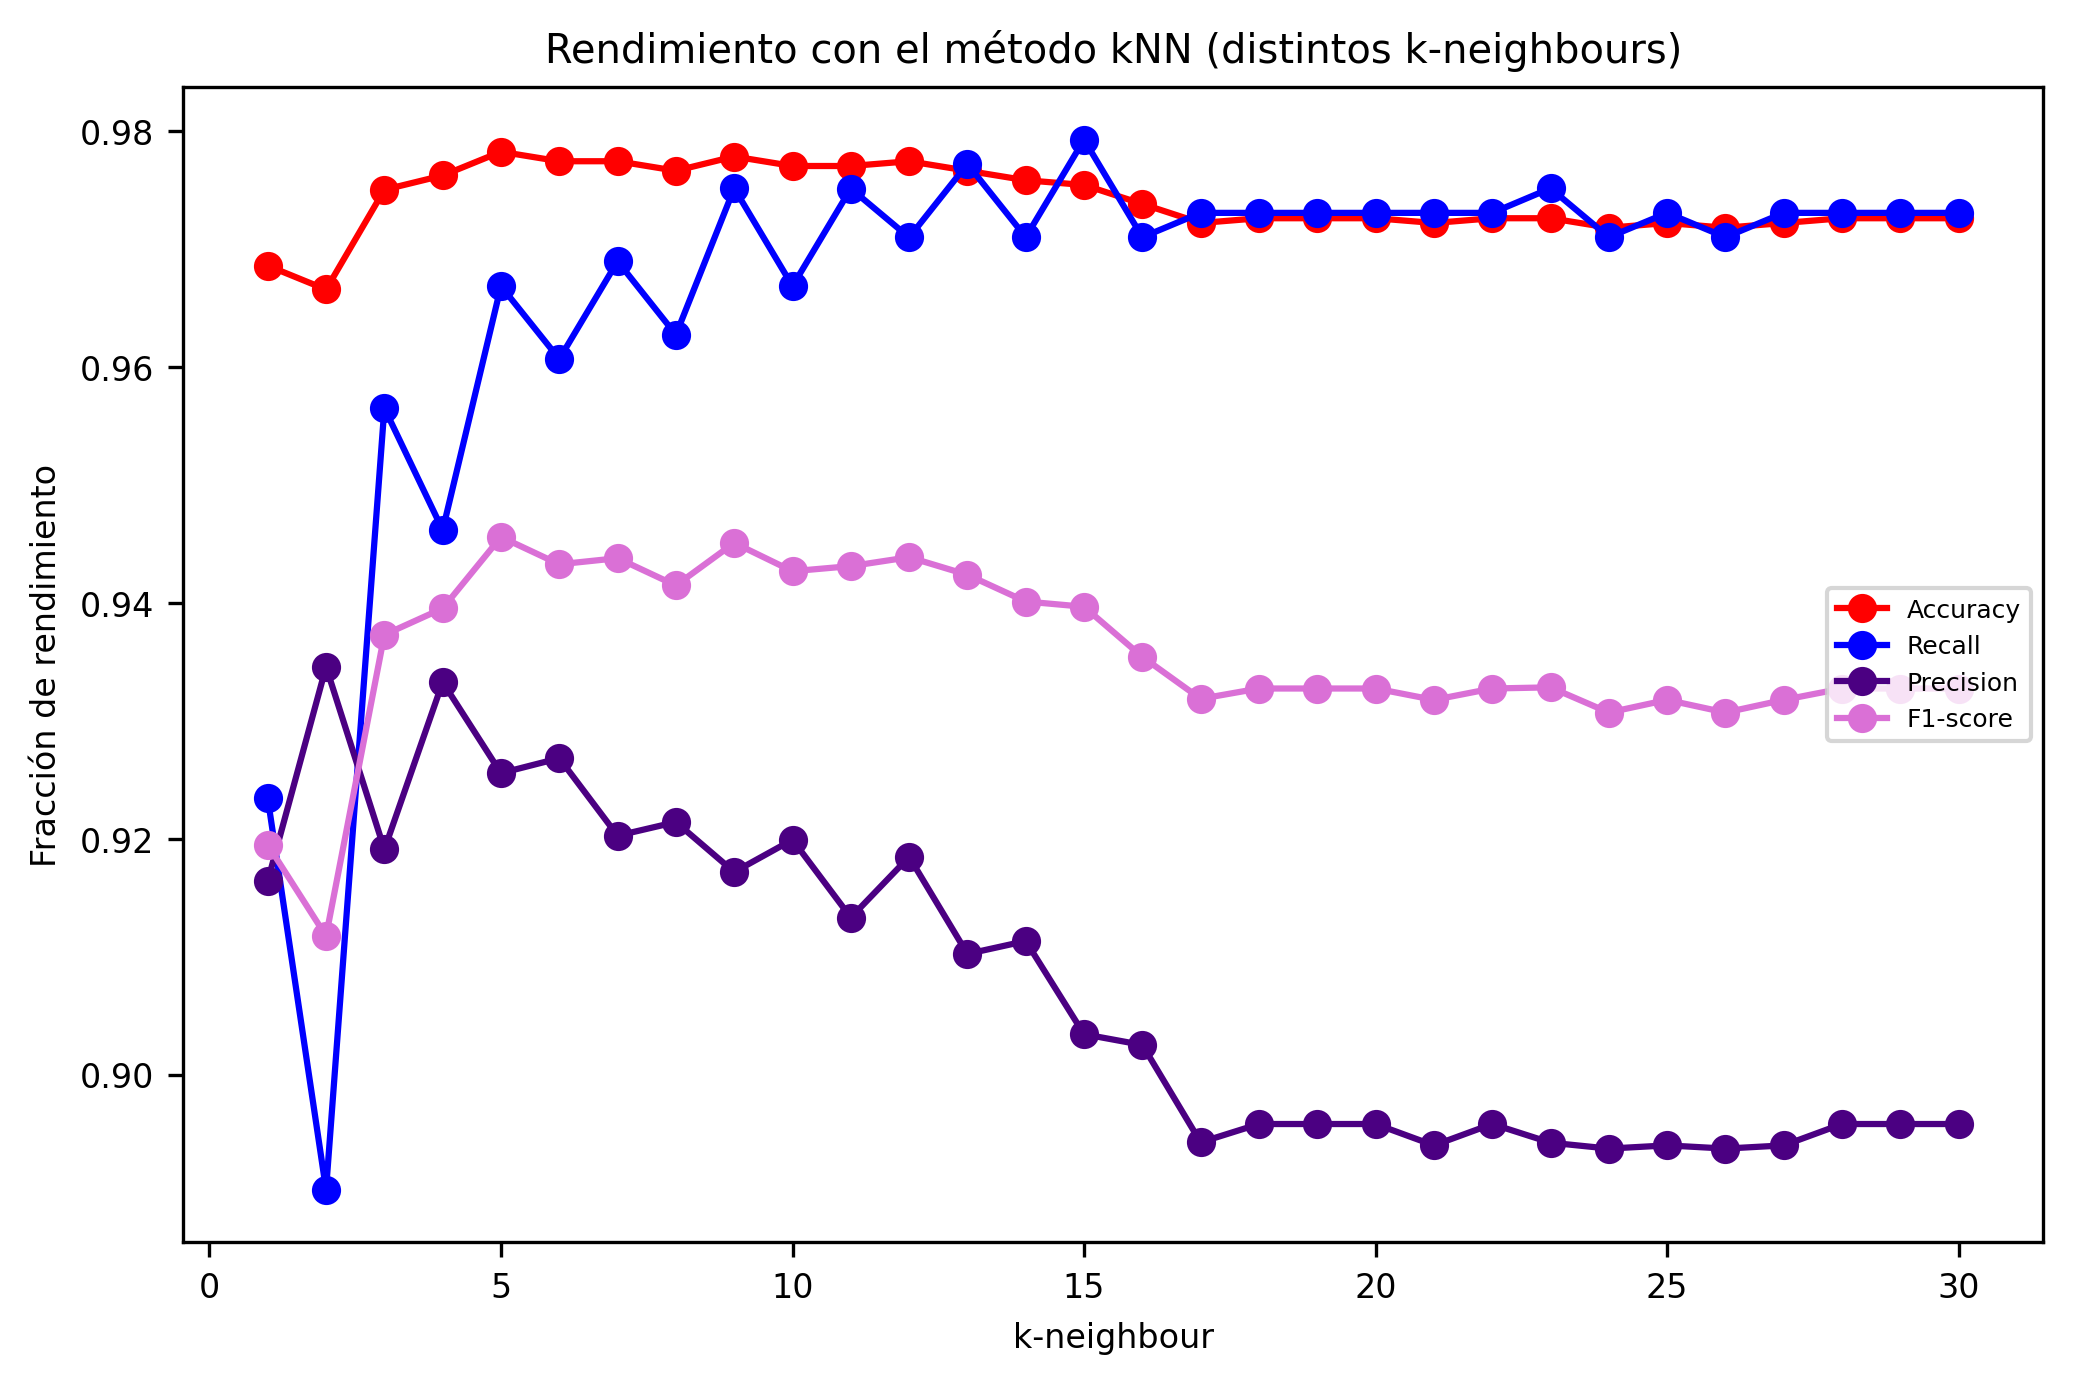

In [476]:
#en esta parte se muestran como varían los distintos valores de métricas usando el método kNN
plt.figure(figsize=(8,5))
plt.plot(ks, accuracy, marker="o", label="Accuracy",color="red")
plt.plot(ks, recall, marker="o", label="Recall",color="blue")
plt.plot(ks, precision, marker="o", label="Precision",color="indigo")
plt.plot(ks, f1, marker="o", label="F1-score",color="orchid")
plt.xlabel("k-neighbour")
plt.ylabel("Fracción de rendimiento")
plt.title("Rendimiento con el método kNN (distintos k-neighbours)")
plt.legend(loc="center right",fontsize=6)
#plt.xlim(0,4)
plt.show()

### Preguntas
1. ¿Cómo se compara el rendimiento de kNN con el del árbol simple?
   Respecto con el árbol simple en el que se considera una profundidad máxima de 3, al ver los gráficos de recall y de accuracy, para el primero (completitud) en el árbol el rendimiento para los datos trabajados con cross validation está entre 0.90 y 0.96, y con el método de kNN para 30 neighbours va desde un poco menos que 0.90 hasta alrededor de 0.97. Mientras que para el accuracy en el árbol simple los valores van desde más de 0.96 a un poco menos que 0.98, y en para el kNN entre 0.96 y 0.98 también, pero que se queda casi constante alrededor de 0.97. Luego el rendimiento de kNN quizás puede ser mayor, pero puede sufrir de alto sesgo debido a que se escogen neighbours específicos. Además para un modelo muy simple (excesivamente) puede aludirse a que va a existir un alto sesgo, mientras que por otra parte, al tener alta varianza se puede asociar a una generalización muy deficiente debido a un modelo muy complejo (como el primer modelo de árbol, el "árbol base").
3. ¿Qué ocurre cuando `k` es muy pequeño? Cuando k es muy pequeño se ven valores de rendimiento muy variables para las distintas métricas, se puede decir que son "inestables". Luego hay mucha varianza.
4. ¿Qué ocurre cuando `k` es muy grande? Mientras que para este caso, de k con tendencia a ser mayor los valores de rendimiento tienen una tendencia casi constante desde k=17 aproximadamente. Luego como se consideran varios k, hay menos varianza y más sesgo con tendencias.
5. ¿Qué valor de `k` parece dar el mejor equilibrio entre precision y recall? Si es que la pregunta se refiere a cuál es el mejor valor entre los dos, sería k=1 porque los valores son cercanos, si es que es para cuando se "cruzan" esos valores sería k=2.5 (aprox.) y si es que se busca el equilibrio donde sus valores tienden a estabilizarse sería k=17.
6. ¿Qué ventaja podría tener kNN si la frontera entre clases no es rectangular? Considerando que para un learning set pequeño, kNN no serviría o en realidad no sería lo más óptimo puesto que se encontraría cerca de los límites de la distribución del learning set mismo. Para una frontera entre clases no rectangular se tendría una mayor "visión" y ampliación como búsqueda de valores y vecinos cercanos dependiendo de features específicas. Además el considerar más data ayudaría a tener un mejor alcance a valores de rendimiento específico.

No así como por ejemplo para los DT, que están limitados por los splits rectangulares a partir de los features otorgados, los mismos algoritmos que permiten hacer un mapeo a los features en un espacio dimensional más grande van a funcionar mejor. Aunque si hay mucha profundidad debido a un árbol complejo, puede existir un sobreajuste lo que no es deseado para poder concluir sobre el modelo.

## Cierre

En esta actividad vimos que evaluar un clasificador no consiste solo en obtener un score alto, sino en interpretar qué está midiendo cada métrica y cómo se construyen los conjuntos de validación. En este problema, el uso de validación cruzada estratificada fue importante para obtener una evaluación más estable y representativa.

También observamos que un modelo más complejo no siempre generaliza mejor. Aunque el árbol base ajustaba perfectamente los datos de entrenamiento, un árbol más simple logró mejores resultados en validación cruzada, lo que sugiere que reducir la complejidad ayudó a disminuir el sobreajuste.

En general, para los modelos se tienen que hacer como preguntas de hipótesis, luego se explora el data en conjunto con los features y targets, además de la estadística como mean, median, etc. Después se puede escoger una métrica y además evaluar entre métricas y dependiendo del modelo se realiza un pre-procesamiento y se describen si es que hay outliers, también una escala de los datos o data que se ha perdido o que es innecesario, luego se van analizando y haciendo cross-validation en conjunto con high bias (altos sesgos posibles) y high variance (altas varianzas posibles). Posteriormente, se ven las consecuencias que conllevan los conceptos.